# Query-Efficient Model Extraction of Vision Foundation Models — Kaggle Starter

Yeh notebook aapke research proposal ka **Phase I–V (pilot / feasibility stage)** implement karta hai, CIFAR-10 par, taakay Kaggle ke free GPU (T4 x2 / P100) par chal sake.

**Covers:**
1. Victim models (CNN aur ViT) train karna
2. Simulated black-box query API
3. Attacker candidate pool + embeddings
4. Baseline query strategies: random, uncertainty, diversity
5. Proposed adaptive strategy `S(x) = α·U(x) + β·D(x) + γ·I(x)`
6. Surrogate training + fidelity evaluation (RQ1–RQ3)
7. **Bonus:** simple stealth-feature detector + adaptive defense (RQ4–RQ5, chhota version)

**Settings (Kaggle):** Notebook -> Settings -> Accelerator -> GPU T4 x2 (ya P100). Internet ON honi chahiye (pretrained weights download karne ke liye).

> CLIP victim aur ImageNet scale-up baad mein add karenge (Section 19 ka staged design) — pehle yeh CIFAR-10 pilot solid banayein, phir extend karein.


## ⚠️ Honest Scope Statement (read before writing the paper)

This notebook runs on a **free-tier single-GPU budget** (Kaggle/Colab T4, ~15GB, ~30hr quota). Given that constraint:

- **What this notebook supports as a paper claim:** a pilot-scale empirical study of the proposed adaptive query-selection strategy and stealth/defense mechanisms, on CIFAR-10 (ResNet-18/CNN surrogate) with a small-scale ImageNet-derived (Imagenette) generalization check, using **5-seed statistics with 95% confidence intervals** for the core comparisons.
- **What it does NOT support:** claims at the full scale described in the original proposal (ViT-B/16, CLIP ViT-B/16, full ImageNet, full victim×surrogate factorial matrix, full ablation suite). Those remain future work.
- **Why this matters for review:** a paper that explicitly scopes itself as "pilot-scale study with rigorous statistics on a constrained compute budget, positioned as a stepping stone to full-scale evaluation" is defensible. A paper that reports pilot-scale numbers while claiming full-scale generality is not — reviewers will catch the mismatch and reject on that basis alone, independent of whether the method itself is sound.
- **Recommended framing for the paper's scope/limitations section:** state the GPU budget explicitly, state the architectures actually tested, and present the full-scale design (Section 19 of the proposal) as the described-but-not-yet-run follow-up. This is normal, accepted practice — many strong systems-security papers report scoped pilot studies and are explicit about what larger-scale validation would add.


In [2]:
# --- Setup ---
import os, time, random, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --- Environment detection: makes all paths portable across Colab / Kaggle / local ---
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DRIVE_BACKUP_DIR = None
DRIVE_MOUNTED = False

# Drive mount is opportunistic only -- never fatal. Some environments (including some
# Kaggle images) can import `google.colab` without actually being a real Colab runtime,
# in which case drive.mount() raises NotImplementedError. We catch that (and anything
# else) and just skip the Drive backup rather than aborting the whole notebook.
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")   # will prompt an auth popup the first time -- click through it
        DRIVE_BACKUP_DIR = "/content/drive/MyDrive/model_extraction_vfm_checkpoints"
        os.makedirs(DRIVE_BACKUP_DIR, exist_ok=True)
        DRIVE_MOUNTED = True
    except Exception as e:
        print(f"(Drive mount skipped -- not available in this environment: {type(e).__name__}: {e})")
        DRIVE_BACKUP_DIR = None
        DRIVE_MOUNTED = False

# Decide WORKDIR by actual filesystem, checked BEFORE trusting the IN_COLAB flag --
# this is what makes the Kaggle-with-importable-google.colab case resolve correctly.
if os.path.exists("/kaggle/working"):
    WORKDIR = "/kaggle/working"
elif IN_COLAB:
    WORKDIR = "/content/working"
else:
    WORKDIR = os.path.abspath("./working")

os.makedirs(WORKDIR, exist_ok=True)
env_name = "Kaggle" if WORKDIR == "/kaggle/working" else ("Colab" if IN_COLAB else "Local")
print(f"Environment: {env_name}  ->  WORKDIR = {WORKDIR}")
if DRIVE_MOUNTED:
    print(f"Drive mounted. Checkpoints will auto-backup to: {DRIVE_BACKUP_DIR}")
else:
    print("(No Drive backup -- this environment's storage already persists checkpoints, or Drive isn't available here.)")


Device: cuda
(Drive mount skipped -- not available in this environment: NotImplementedError: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.)
Environment: Kaggle  ->  WORKDIR = /kaggle/working
(No Drive backup -- this environment's storage already persists checkpoints, or Drive isn't available here.)


## ⏱️ 30-Hour GPU Budget Plan (Kaggle free quota)

Kaggle free tier: **30 GPU-hrs/week**, session max **12 hrs**, quota **Saturday ko reset** hota hai. Is notebook ko is budget ke andar poora karne ka plan:

| Slot | Kaam | Approx. GPU time |
|---|---|---|
| 1 | Victim CNN train + victim ViT train (linear probe, 2–3 epochs) | ~1.5 hrs |
| 2 | Embeddings pre-compute (pool + encoder) | ~0.5 hr |
| 3 | Strategy comparison @ 1 fixed budget (random/uncertainty/diversity/adaptive) — CNN victim only | ~3 hrs |
| 4 | Repeat Slot 3 for ViT victim (RQ1/H1) | ~3 hrs |
| 5 | Budget sweep (200/500/1000) — adaptive vs random only, CNN victim | ~3 hrs |
| 6 | Stealth detector + defense demo (cheap, CPU-ish) | ~0.5 hr |
| 7 | Buffer / re-runs / plotting / write-up | ~2 hrs |
| **Total (1 seed, 2 victims, CIFAR-10 only)** | | **~13–14 hrs** — fits in 1 week easily |

Baaki ~16 hrs is haftay reserve rakhein CLIP victim ya ImageNet-subset scale-up ke liye (agla week bhi mil sakta hai — quota weekly resets hota hai, is liye **poora multi-phase project 2–3 weeks mein split** karna sabse realistic hai, ek hi 30-hr window mein nahi).

**Scope jo *drop/reduce* karein taake 30 hrs mein fit ho:**
- CLIP victim → Week 2 ke liye chhor dein (stretch goal), pehle CNN+ViT solid results nikalein.
- 5 seeds ki jagah **1 seed** rakhein pilot ke liye; multi-seed sirf final chosen configs par (paper-writing stage mein).
- Full factorial matrix (3×3 surrogate×victim) ki jagah sirf **matched pairs** (CNN↔CNN, ViT↔ViT) + **1 mismatched pair** chalayein.
- Query budget sweep `[200, 500, 1000]` tak rakhein — `5000`/`10000` sirf best-2 strategies ke liye, agar time bache.
- `surrogate_epochs_per_round=1` rakhein (notebook mein already hai) — 2+ se time bahut barh jata hai.

**Session-limit ka masla (12 hrs/session):** har major phase ke baad checkpoint save karein (neeche wala cell) taake session expire/restart ho to dobara se shuru na karna paray — bas checkpoint load karke aagay barhein.


In [3]:
import os, json, time, shutil
CKPT_DIR = f"{WORKDIR}/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

# --- Kaggle persistence note -------------------------------------------------
# /kaggle/working is NOT guaranteed to survive a session reset, a kernel restart
# after hitting the 12-hr session cap, or you closing the browser tab and Kaggle
# recycling the session. The only storage that reliably survives across separate
# sessions is a Kaggle DATASET (created from a "Save Version" with output files,
# or pushed via the Kaggle API). So the workflow this notebook expects is:
#
#   1. Run a phase, checkpoints land in CKPT_DIR (via save_ckpt below).
#   2. Call backup_now() (defined below) after each major phase. It zips
#      CKPT_DIR into WORKDIR/checkpoint_backup.zip.
#   3. Before your session ends (or the 12-hr cap hits), go to
#      File -> Save Version -> Save & Run All (or "Quick Save") so the zip is
#      captured as output. That committed version is now a Kaggle Dataset
#      ("Output" tab of that version) you can reuse.
#   4. Next session: click "Add Data" -> "Your Datasets" -> pick that output
#      dataset, and set KAGGLE_CKPT_INPUT_NAME below to its input folder name
#      (shown under /kaggle/input/<name>/). This cell restores from it
#      automatically, so cells with load_ckpt(...) skip already-finished work.
#
# If you don't do step 3/4, /kaggle/working may still happen to survive a
# same-day reconnect, but do not rely on that for anything you can't afford
# to recompute.

# List every /kaggle/input/<name>/ folder that might hold checkpoint zips or .pt files.
# "projectoutput" is this notebook's own auto-generated output dataset (from Save Version) --
# harmless to list even if it doesn't have checkpoints in it. Add your manually-uploaded
# checkpoint dataset's name here too (e.g. "aspkd-checkpoint-backup").
KAGGLE_CKPT_INPUT_NAMES = ["projectoutput", "aspkd-checkpoint-backup"]

# Separately: the Imagenette dataset used by the scale-up phase. This is NOT scanned for
# checkpoints -- it's used directly by IMAGENETTE_PATH later in the notebook.
KAGGLE_IMAGENETTE_INPUT_NAME = "fastai-imagenette-fullsize"

IN_KAGGLE = os.path.exists("/kaggle/working")
KAGGLE_INPUT_CKPT_DIRS = []
if IN_KAGGLE:
    import glob as _glob
    # Kaggle sometimes mounts datasets at /kaggle/input/<name>/ and sometimes at the
    # nested /kaggle/input/datasets/<user>/<name>/ -- search both so restore works either way.
    for _name in KAGGLE_CKPT_INPUT_NAMES:
        _flat = f"/kaggle/input/{_name}"
        if os.path.isdir(_flat):
            KAGGLE_INPUT_CKPT_DIRS.append(_flat)
        for _nested in _glob.glob(f"/kaggle/input/**/{_name}", recursive=True):
            if os.path.isdir(_nested) and _nested not in KAGGLE_INPUT_CKPT_DIRS:
                KAGGLE_INPUT_CKPT_DIRS.append(_nested)

# --- Restore-on-reconnect: pull any previously-backed-up checkpoints into WORKDIR
# *now*, before anything else runs, so load_ckpt() below finds them and the
# notebook skips re-computing work that already finished in an earlier session.
# Handles both the Colab-Drive case and the Kaggle-input-dataset case. Safe to
# run even if nothing was backed up yet.
def _restore_checkpoints():
    restored = 0
    unzipped = 0
    sources = []
    if IN_COLAB and DRIVE_BACKUP_DIR and os.path.isdir(DRIVE_BACKUP_DIR):
        sources.append(DRIVE_BACKUP_DIR)
    sources.extend(KAGGLE_INPUT_CKPT_DIRS)

    for src_dir in sources:
        # unzip ANY .zip found in the source dir (covers old backup names like
        # "aspkd_checkpoint_backup.zip" as well as the current "checkpoint_backup.zip",
        # and lets you drop in multiple old zips from different runs -- later files
        # win only if you extract in a meaningful order, so keep this to one zip
        # per dataset if you can)
        for fname in os.listdir(src_dir):
            if fname.endswith(".zip"):
                zip_path = os.path.join(src_dir, fname)
                shutil.unpack_archive(zip_path, CKPT_DIR)
                unzipped += 1
                print(f"Unpacked {zip_path} into {CKPT_DIR}")
        # also copy any loose .pt/.pth files sitting directly in the source dir
        for fname in os.listdir(src_dir):
            src_path = os.path.join(src_dir, fname)
            dst_path = os.path.join(CKPT_DIR, fname)
            if os.path.isfile(src_path) and fname.endswith(('.pt', '.pth')) and not os.path.exists(dst_path):
                shutil.copy2(src_path, dst_path)
                restored += 1

    n_ckpt_files = len([f for f in os.listdir(CKPT_DIR) if f.endswith(('.pt', '.pth'))]) if os.path.isdir(CKPT_DIR) else 0
    print(f"Restore summary: {unzipped} zip(s) unpacked, {restored} loose file(s) copied -> {n_ckpt_files} checkpoint file(s) now in {CKPT_DIR}")
    if n_ckpt_files:
        for f in sorted(os.listdir(CKPT_DIR)):
            if f.endswith(('.pt', '.pth')):
                print("   -", f)
        print("  -> cells below that call load_ckpt(...) first will pick these up and skip re-running.")
    elif not sources:
        print("  (no prior backup source configured/found -- fresh run, or set KAGGLE_CKPT_INPUT_NAME above)")

_restore_checkpoints()

def save_ckpt(name, **kwargs):
    path = os.path.join(CKPT_DIR, name)
    torch.save(kwargs, path)
    print("saved:", path)
    if IN_COLAB and DRIVE_BACKUP_DIR:
        drive_path = os.path.join(DRIVE_BACKUP_DIR, name)
        shutil.copy2(path, drive_path)
        print("  also backed up to Drive:", drive_path)

def load_ckpt(name):
    path = os.path.join(CKPT_DIR, name)
    if os.path.exists(path):
        print("loading:", path)
        return torch.load(path, map_location=device, weights_only=False)
    return None

def backup_now(label=""):
    """Re-zip everything in CKPT_DIR to WORKDIR/checkpoint_backup.zip.
    Call this after every major phase (not just at the very end), so that if
    the session dies before you reach the final backup cell, you still have a
    zip ready to be captured by 'Save Version' on Kaggle, or already mirrored
    to Drive on Colab. Idempotent and cheap -- only re-zips existing .pt files."""
    zip_base = f"{WORKDIR}/checkpoint_backup"
    shutil.make_archive(zip_base, 'zip', CKPT_DIR)
    size_mb = os.path.getsize(zip_base + ".zip") / (1024*1024)
    tag = f" [{label}]" if label else ""
    print(f"backup_now(){tag}: {zip_base}.zip refreshed ({size_mb:.1f} MB, {len(os.listdir(CKPT_DIR))} files in {CKPT_DIR})")
    if IN_KAGGLE:
        print("  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.")

class Timer:
    """Track cumulative GPU-wallclock time used in this notebook session so you can watch the 30-hr budget."""
    def __init__(self):
        self.total = 0.0
        self._t0 = None
    def start(self):
        self._t0 = time.time()
    def stop(self, label=""):
        elapsed = time.time() - self._t0
        self.total += elapsed
        print(f"[{label}] {elapsed/60:.1f} min this step | {self.total/3600:.2f} hrs total this session")

timer = Timer()


Restore summary: 0 zip(s) unpacked, 1 loose file(s) copied -> 22 checkpoint file(s) now in /kaggle/working/checkpoints
   - aspkd_proxy_data.pt
   - aspkd_proxy_partial.pt
   - aspkd_results.pt
   - budget_sweep_results.pt
   - clip_results.pt
   - detector_v3.pt
   - full_budget_sweep.pt
   - imagenette_results.pt
   - multiseed_adaptive.pt
   - multiseed_random.pt
   - stealix_lite_results.pt
   - stealth_sessions.pt
   - strategy_comparison_results.pt
   - tradeoff_curve.pt
   - tradeoff_results.pt
   - udi_ablation.pt
   - victim_clip.pt
   - victim_cnn.pt
   - victim_cnn_imagenette.pt
   - victim_vit.pt
   - vit_results.pt
   - weight_grid_search.pt
  -> cells below that call load_ckpt(...) first will pick these up and skip re-running.


## Storage Management (run this whenever /kaggle/working is getting full)

`backup_now()` above already keeps a single, self-overwriting `checkpoint_backup.zip` --
that's the only backup file you need. The three cells below (a) show what's actually using
space, (b) delete any duplicate/stale backup zips from earlier debugging, and (c) prune
resume-only partial-checkpoint files once their final result already exists. All three are
safe to re-run any time -- they never touch anything still needed to resume the notebook.

In [4]:
import os
sizes = []
for root, dirs, files in os.walk(WORKDIR):
    for f in files:
        p = os.path.join(root, f)
        sizes.append((os.path.getsize(p), p))
sizes.sort(reverse=True)
total = sum(s for s, _ in sizes) / (1024**3)
print(f"Total: {total:.2f} GiB\n")
for s, p in sizes[:25]:
    print(f"{s/(1024**2):8.1f} MB   {p}")


Total: 4.20 GiB

  2105.8 MB   /kaggle/working/checkpoints/aspkd_proxy_partial.pt
   166.2 MB   /kaggle/working/checkpoint_backup.zip
   162.6 MB   /kaggle/working/data/cifar-10-python.tar.gz
    82.7 MB   /kaggle/working/checkpoints/victim_vit.pt
    42.7 MB   /kaggle/working/checkpoints/victim_cnn_imagenette.pt
    42.7 MB   /kaggle/working/checkpoints/victim_cnn.pt
    29.6 MB   /kaggle/working/data/cifar-10-batches-py/data_batch_3
    29.6 MB   /kaggle/working/data/cifar-10-batches-py/data_batch_1
    29.6 MB   /kaggle/working/data/cifar-10-batches-py/data_batch_4
    29.6 MB   /kaggle/working/data/cifar-10-batches-py/data_batch_5
    29.6 MB   /kaggle/working/data/cifar-10-batches-py/test_batch
    29.6 MB   /kaggle/working/data/cifar-10-batches-py/data_batch_2
    27.3 MB   /kaggle/working/checkpoints/aspkd_proxy_data.pt
     7.0 MB   /kaggle/working/imagenette2/train/n01440764/n01440764_13368.JPEG
     4.5 MB   /kaggle/working/imagenette2/train/n03417042/n03417042_3003.JPEG
    

In [5]:
import glob, os
KEEP = {os.path.join(WORKDIR, "checkpoint_backup.zip")}
redundant_patterns = [
    f"{WORKDIR}/aspkd_final_backup.zip",
    f"{WORKDIR}/aspkd_checkpoint_backup.zip",
    f"{WORKDIR}/notebook_backup.zip",
    f"{WORKDIR}/full_notebook_backup_*.zip",   # catches every timestamped duplicate
]
freed = 0
for pattern in redundant_patterns:
    for p in glob.glob(pattern):
        if p not in KEEP and os.path.exists(p):
            freed += os.path.getsize(p)
            os.remove(p)
            print("deleted:", p)
print(f"\nFreed: {freed/(1024**3):.2f} GiB")



Freed: 0.00 GiB


In [6]:
import os
pairs = [  # (partial file, final file that supersedes it)
    ("aspkd_proxy_partial.pt", "aspkd_results.pt"),
    ("stealix_lite_partial.pt", "stealix_lite_results.pt"),
]
for partial, final in pairs:
    pp, fp = os.path.join(CKPT_DIR, partial), os.path.join(CKPT_DIR, final)
    if os.path.exists(pp) and os.path.exists(fp):
        os.remove(pp)
        print("removed stale partial:", partial, "(final result already saved)")


removed stale partial: aspkd_proxy_partial.pt (final result already saved)


## Phase I — Victim Model Construction

Do victim families train karenge: **ResNet-18** (CNN baseline — proposal mein ResNet-50 suggest hai, but ResNet-18 Kaggle pilot ke liye tez hai) aur **ViT-B/16-ish small ViT** (`timm` se). Baad mein isi pattern se ViT-B/16 full aur CLIP add kar sakte hain.

Dataset ko 2 hisso mein split karenge:
- **Victim private split** — sirf victim training ke liye (attacker isay kabhi access nahi karta)
- **Public candidate pool** — attacker jahan se query karega (disjoint dataset — Objective/Phase II requirement)


In [7]:
!pip install timm -q
import timm


In [8]:
# --- Data ---
mean, std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
train_tf = T.Compose([T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(), T.ToTensor(), T.Normalize(mean, std)])
eval_tf  = T.Compose([T.ToTensor(), T.Normalize(mean, std)])

full_train = torchvision.datasets.CIFAR10(root=f"{WORKDIR}/data", train=True, download=True, transform=train_tf)
full_train_eval = torchvision.datasets.CIFAR10(root=f"{WORKDIR}/data", train=True, download=True, transform=eval_tf)
test_set  = torchvision.datasets.CIFAR10(root=f"{WORKDIR}/data", train=False, download=True, transform=eval_tf)

# split: 50% victim-private, 50% attacker candidate pool (disjoint, log the split -> Phase II step 3)
idx = list(range(len(full_train)))
random.shuffle(idx)
victim_idx = idx[:25000]
pool_idx   = idx[25000:]
print("Overlap check (must be 0):", len(set(victim_idx) & set(pool_idx)))

victim_train = Subset(full_train, victim_idx)
candidate_pool = Subset(full_train_eval, pool_idx)   # eval transform: attacker just queries, no augmentation

victim_loader = DataLoader(victim_train, batch_size=128, shuffle=True, num_workers=2)
test_loader   = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)
classes = full_train.classes
print(len(victim_train), "victim-private images |", len(candidate_pool), "attacker candidate-pool images")


Overlap check (must be 0): 0
25000 victim-private images | 25000 attacker candidate-pool images


In [9]:
# --- Victim model builders ---
def build_cnn_victim():
    m = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, 10)
    return m.to(device)

def build_vit_victim():
    m = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=10)
    return m.to(device)

VIT_INPUT = 224  # ViT needs resizing from 32x32 -> 224x224
resize_for_vit = T.Resize((VIT_INPUT, VIT_INPUT))

def maybe_resize(x, arch):
    return resize_for_vit(x) if arch == "vit" else x


In [10]:
# --- Fine-tune a victim (linear probe by default; set full_finetune=True for full FT) ---
# Uses mixed precision (AMP) -- roughly 1.5-2x faster on Kaggle's T4/P100, which matters a lot
# when you're watching a 30-hr weekly quota.
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

def train_victim(arch="cnn", epochs=3, full_finetune=False, lr=1e-3):
    model = build_cnn_victim() if arch == "cnn" else build_vit_victim()

    if not full_finetune:
        for name, p in model.named_parameters():
            if arch == "cnn" and "fc" not in name:
                p.requires_grad = False
            if arch == "vit" and "head" not in name:
                p.requires_grad = False

    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    crit = nn.CrossEntropyLoss()

    model.train()
    for ep in range(epochs):
        total, correct, loss_sum = 0, 0, 0.0
        for x, y in victim_loader:
            x, y = maybe_resize(x, arch).to(device), y.to(device)
            opt.zero_grad()
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                out = model(x)
                loss = crit(out, y)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item(); total += x.size(0)
        print(f"[{arch}] epoch {ep+1}/{epochs} loss={loss_sum/total:.4f} acc={correct/total:.4f}")
    return model

@torch.no_grad()
def evaluate(model, loader, arch="cnn"):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = maybe_resize(x, arch).to(device), y.to(device)
        out = model(x)
        correct += (out.argmax(1) == y).sum().item(); total += x.size(0)
    return correct / total

# Train the CNN victim (fast pilot), with a checkpoint so a session restart doesn't cost you the GPU time.
timer.start()
ckpt = load_ckpt("victim_cnn.pt")
victim_cnn = build_cnn_victim()
if ckpt:
    victim_cnn.load_state_dict(ckpt["state_dict"])
else:
    victim_cnn = train_victim(arch="cnn", epochs=3, full_finetune=False)
    save_ckpt("victim_cnn.pt", state_dict=victim_cnn.state_dict())
print("Victim CNN clean test accuracy:", evaluate(victim_cnn, test_loader, "cnn"))
timer.stop("victim_cnn training")

# ViT victim -- run this in Slot 1 too if your 30-hr budget allows both victims this week (see plan above).
# timer.start()
# ckpt_vit = load_ckpt("victim_vit.pt")
# victim_vit = build_vit_victim()
# if ckpt_vit:
#     victim_vit.load_state_dict(ckpt_vit["state_dict"])
# else:
#     victim_vit = train_victim(arch="vit", epochs=2, full_finetune=False)
#     save_ckpt("victim_vit.pt", state_dict=victim_vit.state_dict())
# print("Victim ViT clean test accuracy:", evaluate(victim_vit, test_loader, "vit"))
# timer.stop("victim_vit training")
backup_now("Phase I CNN victim training")


loading: /kaggle/working/checkpoints/victim_cnn.pt


/tmp/ipykernel_821/4112139943.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Victim CNN clean test accuracy: 0.3946
[victim_cnn training] 0.0 min this step | 0.00 hrs total this session
backup_now() [Phase I CNN victim training]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


## Phase I.3 — Simulated Query API

Yeh function ek MLaaS-style API simulate karta hai: attacker sirf input bhejta hai, response mein **hard label**, **top-k**, ya **full confidence vector** milta hai (configurable — Section 9.1 "Output knowledge variants").


In [11]:
class VictimAPI:
    """Simulated black-box MLaaS endpoint."""
    def __init__(self, model, arch="cnn", output_mode="soft"):
        self.model = model.eval()
        self.arch = arch
        self.output_mode = output_mode  # "hard" | "soft" | "topk"
        self.query_count = 0

    @torch.no_grad()
    def query(self, x_batch, k=3):
        self.query_count += x_batch.size(0)
        x_batch = maybe_resize(x_batch, self.arch).to(device)
        logits = self.model(x_batch)
        probs = F.softmax(logits, dim=1)
        if self.output_mode == "hard":
            return F.one_hot(probs.argmax(1), num_classes=probs.size(1)).float().cpu()
        elif self.output_mode == "topk":
            topv, topi = probs.topk(k, dim=1)
            out = torch.zeros_like(probs)
            out.scatter_(1, topi, topv)
            return out.cpu()
        else:
            return probs.cpu()

victim_api = VictimAPI(victim_cnn, arch="cnn", output_mode="soft")


## Phase II — Candidate Query Pool + Embedding Index

Diversity term `D(x)` ke liye har candidate image ka embedding pre-compute karte hain (surrogate-independent small encoder — yahan hum pool par pretrained ResNet18 ka penultimate-layer feature use kar rahe hain, jaisa proposal ka step 15 kehta hai).


In [12]:
encoder = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
encoder.fc = nn.Identity()
encoder = encoder.to(device).eval()

@torch.no_grad()
def compute_embeddings(dataset, batch_size=256):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    embs = []
    for x, _ in loader:
        e = encoder(x.to(device))
        embs.append(F.normalize(e, dim=1).cpu())
    return torch.cat(embs, dim=0)

pool_embeddings = compute_embeddings(candidate_pool)
print("Pool embeddings:", pool_embeddings.shape)


Pool embeddings: torch.Size([25000, 512])


## Phase III — Baseline Query-Selection Strategies

`random`, `class-balanced`, `uncertainty` (entropy), `diversity` (farthest-point / min-distance-to-selected). Har strategy ek round mein `batch_size` candidates chunti hai.

In [13]:
def random_strategy(surrogate, arch, pool_idx_available, embeddings, selected_idx, batch_size):
    return random.sample(list(pool_idx_available), min(batch_size, len(pool_idx_available)))

@torch.no_grad()
def uncertainty_scores(surrogate, arch, indices):
    surrogate.eval()
    loader = DataLoader(Subset(candidate_pool, indices), batch_size=256, shuffle=False)
    scores = []
    for x, _ in loader:
        x = maybe_resize(x, arch).to(device)
        p = F.softmax(surrogate(x), dim=1)
        entropy = -(p * (p.clamp_min(1e-9)).log()).sum(1)
        scores.append(entropy.cpu())
    return torch.cat(scores)

def uncertainty_strategy(surrogate, arch, pool_idx_available, embeddings, selected_idx, batch_size):
    idx_list = list(pool_idx_available)
    scores = uncertainty_scores(surrogate, arch, idx_list)
    top = torch.topk(scores, min(batch_size, len(idx_list))).indices
    return [idx_list[i] for i in top.tolist()]

def diversity_strategy(surrogate, arch, pool_idx_available, embeddings, selected_idx, batch_size):
    idx_list = list(pool_idx_available)
    if len(selected_idx) == 0:
        return random.sample(idx_list, min(batch_size, len(idx_list)))
    sel_emb = embeddings[list(selected_idx)]
    chosen = []
    remaining = idx_list.copy()
    for _ in range(min(batch_size, len(idx_list))):
        rem_emb = embeddings[remaining]
        ref_emb = embeddings[list(selected_idx) + chosen] if chosen else sel_emb
        d = torch.cdist(rem_emb, ref_emb).min(dim=1).values  # min distance to already-selected/queried
        pick = remaining[torch.argmax(d).item()]
        chosen.append(pick)
        remaining.remove(pick)
    return chosen

def class_balanced_strategy(surrogate, arch, pool_idx_available, embeddings, selected_idx, batch_size):
    """Class-balanced sampling (proposal Phase III): uses the current surrogate's predicted-label
    distribution over already-queried points as a proxy for victim output statistics, then
    preferentially queries pool candidates predicted to belong to the most underrepresented classes."""
    idx_list = list(pool_idx_available)
    if len(selected_idx) < 20:  # not enough data yet to estimate class balance -> fall back to random
        return random.sample(idx_list, min(batch_size, len(idx_list)))

    surrogate.eval()
    sel_loader = DataLoader(Subset(candidate_pool, list(selected_idx)), batch_size=256, shuffle=False)
    sel_preds = []
    with torch.no_grad():
        for x, _ in sel_loader:
            x = maybe_resize(x, arch).to(device)
            sel_preds.append(surrogate(x).argmax(1).cpu())
    sel_preds = torch.cat(sel_preds)
    n_classes = max(int(sel_preds.max().item()) + 1 if len(sel_preds) else 10, 10)
    counts = torch.bincount(sel_preds, minlength=n_classes).float()
    underrep_order = torch.argsort(counts)  # most underrepresented class first

    pool_loader = DataLoader(Subset(candidate_pool, idx_list), batch_size=256, shuffle=False)
    pool_preds = []
    with torch.no_grad():
        for x, _ in pool_loader:
            x = maybe_resize(x, arch).to(device)
            pool_preds.append(surrogate(x).argmax(1).cpu())
    pool_preds = torch.cat(pool_preds)

    chosen = []
    for cls in underrep_order.tolist():
        if len(chosen) >= batch_size:
            break
        cls_candidates = [idx_list[i] for i in range(len(idx_list)) if pool_preds[i].item() == cls]
        need = batch_size - len(chosen)
        chosen.extend(cls_candidates[:need])
    if len(chosen) < batch_size:
        remaining = [i for i in idx_list if i not in set(chosen)]
        chosen.extend(random.sample(remaining, min(batch_size - len(chosen), len(remaining))))
    return chosen


## Phase IV — Proposed Adaptive Strategy

`S(x) = α·U(x) + β·D(x) + γ·I(x)`

- `U(x)` = surrogate entropy (uncertainty)
- `D(x)` = min-distance to already-queried points (diversity)
- `I(x)` = information-gain proxy — expected surrogate-victim disagreement, approx: KL(surrogate‖victim-so-far-estimate) is not available (victim is black-box), so hum ise **surrogate confidence-margin drop under a quick perturbation** se approximate karte hain (ek chhota, lekin defensible proxy jo grid-search se replace ho sakta hai).


In [14]:
@torch.no_grad()
def info_gain_proxy(surrogate, arch, indices, noise_std=0.05):
    """Simple proxy: sensitivity of surrogate's top-1 confidence to small input noise.
    Higher sensitivity ~ point sits near a decision boundary the surrogate hasn't learned well -> higher expected info gain."""
    surrogate.eval()
    loader = DataLoader(Subset(candidate_pool, indices), batch_size=256, shuffle=False)
    scores = []
    for x, _ in loader:
        x = maybe_resize(x, arch).to(device)
        p0 = F.softmax(surrogate(x), dim=1).max(1).values
        p1 = F.softmax(surrogate(x + noise_std * torch.randn_like(x)), dim=1).max(1).values
        scores.append((p0 - p1).abs().cpu())
    return torch.cat(scores)

def adaptive_strategy(surrogate, arch, pool_idx_available, embeddings, selected_idx, batch_size,
                       alpha=0.4, beta=0.3, gamma=0.3):
    idx_list = list(pool_idx_available)
    U = uncertainty_scores(surrogate, arch, idx_list)
    U = (U - U.min()) / (U.max() - U.min() + 1e-9)

    if len(selected_idx) > 0:
        ref_emb = embeddings[list(selected_idx)]
        D = torch.cdist(embeddings[idx_list], ref_emb).min(dim=1).values
    else:
        D = torch.ones(len(idx_list))
    D = (D - D.min()) / (D.max() - D.min() + 1e-9)

    I = info_gain_proxy(surrogate, arch, idx_list)
    I = (I - I.min()) / (I.max() - I.min() + 1e-9)

    S = alpha * U + beta * D + gamma * I
    top = torch.topk(S, min(batch_size, len(idx_list))).indices
    return [idx_list[i] for i in top.tolist()]


## Phase V — Attack Loop + Surrogate Training (RQ1–RQ3, Objectives 3–4)

Generic attack loop jo koi bhi strategy function le kar chalta hai, victim API ko query karta hai, aur surrogate ko incrementally fine-tune karta hai. Fidelity = victim-surrogate agreement, task accuracy = ground-truth par accuracy.


In [15]:
def build_surrogate(arch="cnn"):
    return build_cnn_victim() if arch == "cnn" else build_vit_victim()

@torch.no_grad()
def compute_fidelity_and_accuracy(surrogate, victim_api, arch, loader):
    surrogate.eval()
    agree, correct, total = 0, 0, 0
    for x, y in loader:
        xin = maybe_resize(x, arch).to(device)
        s_pred = surrogate(xin).argmax(1).cpu()
        v_pred = victim_api.query(x, k=1)
        v_pred = v_pred.argmax(1)   # query() now always returns a [batch, num_classes]-shaped tensor (one-hot for "hard" too)
        agree += (s_pred == v_pred).sum().item()
        correct += (s_pred == y).sum().item()
        total += x.size(0)
    return agree / total, correct / total

def run_extraction(strategy_fn, victim_api, arch="cnn", query_budget=2000, batch_size=200,
                    surrogate_epochs_per_round=2, strategy_kwargs=None):
    strategy_kwargs = strategy_kwargs or {}
    surrogate = build_surrogate(arch)
    opt = torch.optim.Adam(surrogate.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()

    pool_idx_available = set(range(len(candidate_pool)))
    selected_idx = []
    queried_x, queried_y_soft = [], []

    n_rounds = query_budget // batch_size
    for r in range(n_rounds):
        batch_idx = strategy_fn(surrogate, arch, pool_idx_available, pool_embeddings, set(selected_idx), batch_size, **strategy_kwargs) \
                    if strategy_fn.__name__ == "adaptive_strategy" else \
                    strategy_fn(surrogate, arch, pool_idx_available, pool_embeddings, set(selected_idx), batch_size)
        for i in batch_idx:
            pool_idx_available.discard(i)
        selected_idx.extend(batch_idx)

        xb = torch.stack([candidate_pool[i][0] for i in batch_idx])
        yb = victim_api.query(xb)  # soft labels from victim
        queried_x.append(xb); queried_y_soft.append(yb)

        # (re)train surrogate on ALL queried data so far (fine-tune, not from scratch)
        X = torch.cat(queried_x); Ysoft = torch.cat(queried_y_soft)
        ds = TensorDataset(X, Ysoft)
        dl = DataLoader(ds, batch_size=64, shuffle=True)
        surrogate.train()
        for _ in range(surrogate_epochs_per_round):
            for xx, yy in dl:
                xx = maybe_resize(xx, arch).to(device)
                yy = yy.to(device)
                opt.zero_grad()
                out = F.log_softmax(surrogate(xx), dim=1)
                loss = -(yy * out).sum(1).mean()  # soft-label cross-entropy
                loss.backward(); opt.step()

    fidelity, acc = compute_fidelity_and_accuracy(surrogate, victim_api, arch, test_loader)
    return surrogate, fidelity, acc, victim_api.query_count


In [16]:
## Gap-fill: Grid Search + Sensitivity Report for alpha/beta/gamma (proposal step 22)
WEIGHT_GRID = [
    (1.0, 0.0, 0.0), (0.0, 1.0, 0.0), (0.0, 0.0, 1.0),
    (0.34, 0.33, 0.33),
    (0.5, 0.3, 0.2), (0.4, 0.3, 0.3), (0.2, 0.4, 0.4), (0.5, 0.25, 0.25),
]
GRID_SEARCH_BUDGET = 200   # validation slice

timer.start()
_ckpt = load_ckpt("weight_grid_search.pt")
grid_results = _ckpt["grid_results"] if _ckpt else {}

for (a, b, g) in WEIGHT_GRID:
    key = f"{a:.2f}_{b:.2f}_{g:.2f}"
    if key in grid_results:
        print(f"alpha={a:.2f} beta={b:.2f} gamma={g:.2f}  already done -> fidelity={grid_results[key]:.4f}")
        continue
    victim_api.query_count = 0
    _, fidelity, acc, _ = run_extraction(adaptive_strategy, victim_api, arch="cnn",
                                          query_budget=GRID_SEARCH_BUDGET, batch_size=50,
                                          surrogate_epochs_per_round=1,
                                          strategy_kwargs={"alpha": a, "beta": b, "gamma": g})
    grid_results[key] = fidelity
    print(f"alpha={a:.2f} beta={b:.2f} gamma={g:.2f}  fidelity={fidelity:.4f}")
    save_ckpt("weight_grid_search.pt", grid_results=grid_results)

best_key = max(grid_results, key=grid_results.get)
ALPHA_BEST, BETA_BEST, GAMMA_BEST = [float(v) for v in best_key.split("_")]
print(f"\nBest weights: alpha={ALPHA_BEST}, beta={BETA_BEST}, gamma={GAMMA_BEST}  (fidelity={grid_results[best_key]:.4f})")
print("Sensitivity table (for the paper's ablation section):")
for k, v in sorted(grid_results.items(), key=lambda kv: -kv[1]):
    print(f"  {k:20s} fidelity={v:.4f}")

# Propagates to every downstream call automatically -- no other cell needs editing.
adaptive_strategy.__defaults__ = (ALPHA_BEST, BETA_BEST, GAMMA_BEST)
timer.stop("alpha/beta/gamma grid search")
backup_now("Weight grid search")

loading: /kaggle/working/checkpoints/weight_grid_search.pt
alpha=1.00 beta=0.00 gamma=0.00  already done -> fidelity=0.1377
alpha=0.00 beta=1.00 gamma=0.00  already done -> fidelity=0.1914
alpha=0.00 beta=0.00 gamma=1.00  already done -> fidelity=0.2086
alpha=0.34 beta=0.33 gamma=0.33  already done -> fidelity=0.2026
alpha=0.50 beta=0.30 gamma=0.20  already done -> fidelity=0.2040
alpha=0.40 beta=0.30 gamma=0.30  already done -> fidelity=0.2093
alpha=0.20 beta=0.40 gamma=0.40  already done -> fidelity=0.1402
alpha=0.50 beta=0.25 gamma=0.25  already done -> fidelity=0.1243

Best weights: alpha=0.4, beta=0.3, gamma=0.3  (fidelity=0.2093)
Sensitivity table (for the paper's ablation section):
  0.40_0.30_0.30       fidelity=0.2093
  0.00_0.00_1.00       fidelity=0.2086
  0.50_0.30_0.20       fidelity=0.2040
  0.34_0.33_0.33       fidelity=0.2026
  0.00_1.00_0.00       fidelity=0.1914
  0.20_0.40_0.40       fidelity=0.1402
  1.00_0.00_0.00       fidelity=0.1377
  0.50_0.25_0.25       fideli

In [17]:
# --- Run the comparison: random vs uncertainty vs diversity vs adaptive, at a fixed low query budget ---
timer.start()
QUERY_BUDGET = 1000   # low-budget regime, per proposal Section 12.3 / RQ2

# Resumable: reload whatever's already been computed (from this session or restored from Drive),
# and only run the strategies that are still missing. Safe to re-run this cell after a disconnect.
_ckpt = load_ckpt("strategy_comparison_results.pt")
results = _ckpt["results"] if _ckpt else {}

for name, fn in [("random", random_strategy), ("class-balanced", class_balanced_strategy),
                  ("uncertainty", uncertainty_strategy), ("diversity", diversity_strategy),
                  ("adaptive (proposed)", adaptive_strategy)]:
    if name in results:
        print(f"{name:20s} already done (skipping) -> fidelity={results[name]['fidelity']:.4f}")
        continue
    victim_api.query_count = 0
    _, fidelity, acc, nqueries = run_extraction(fn, victim_api, arch="cnn",
                                                 query_budget=QUERY_BUDGET, batch_size=100,
                                                 surrogate_epochs_per_round=1)
    results[name] = {"fidelity": fidelity, "accuracy": acc, "queries": nqueries}
    print(f"{name:20s} fidelity={fidelity:.4f}  surrogate_acc={acc:.4f}  queries={nqueries}")
    save_ckpt("strategy_comparison_results.pt", results=results)  # save after EACH strategy, not just at the end

timer.stop("strategy comparison (5 strategies)")
backup_now("Phase III/IV strategy comparison (CNN)")


loading: /kaggle/working/checkpoints/strategy_comparison_results.pt
random               already done (skipping) -> fidelity=0.3764
class-balanced       already done (skipping) -> fidelity=0.3651
uncertainty          already done (skipping) -> fidelity=0.2751
diversity            already done (skipping) -> fidelity=0.2760
adaptive (proposed)  already done (skipping) -> fidelity=0.3236
[strategy comparison (5 strategies)] 0.0 min this step | 0.00 hrs total this session
backup_now() [Phase III/IV strategy comparison (CNN)]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


In [18]:
## Gap-fill: Leave-One-Out Ablation of U / D / I (Section 13)
def _renorm(a, b, c):
    s = a + b + c
    return (a/s, b/s, c/s) if s > 0 else (a, b, c)

ABLATION_CONFIGS = {
    "full (U+D+I)": (ALPHA_BEST, BETA_BEST, GAMMA_BEST),
    "no U (D+I only)": _renorm(0.0, BETA_BEST, GAMMA_BEST),
    "no D (U+I only)": _renorm(ALPHA_BEST, 0.0, GAMMA_BEST),
    "no I (U+D only)": _renorm(ALPHA_BEST, BETA_BEST, 0.0),
}
ABLATION_BUDGET = 1000   # same as main strategy comparison

timer.start()
_ckpt = load_ckpt("udi_ablation.pt")
ablation_results = _ckpt["ablation_results"] if _ckpt else {}

for name, (a, b, g) in ABLATION_CONFIGS.items():
    if name in ablation_results:
        print(f"{name:20s} already done -> fidelity={ablation_results[name]:.4f}")
        continue
    if name == "full (U+D+I)" and "adaptive (proposed)" in results:
        ablation_results[name] = results["adaptive (proposed)"]["fidelity"]
        save_ckpt("udi_ablation.pt", ablation_results=ablation_results)
        print(f"{name:20s} reused from strategy comparison -> fidelity={ablation_results[name]:.4f}")
        continue
    victim_api.query_count = 0
    _, fidelity, acc, _ = run_extraction(adaptive_strategy, victim_api, arch="cnn",
                                          query_budget=ABLATION_BUDGET, batch_size=100,
                                          surrogate_epochs_per_round=1,
                                          strategy_kwargs={"alpha": a, "beta": b, "gamma": g})
    ablation_results[name] = fidelity
    print(f"{name:20s} alpha={a:.2f} beta={b:.2f} gamma={g:.2f}  fidelity={fidelity:.4f}")
    save_ckpt("udi_ablation.pt", ablation_results=ablation_results)

timer.stop("U/D/I ablation")
full_fid = ablation_results["full (U+D+I)"]
print("\nComponent contribution (drop when a term is removed):")
for name, fid in ablation_results.items():
    if name != "full (U+D+I)":
        print(f"  {name:20s} fidelity={fid:.4f}  (drop={full_fid - fid:+.4f})")
backup_now("U/D/I ablation")

loading: /kaggle/working/checkpoints/udi_ablation.pt
full (U+D+I)         already done -> fidelity=0.3236
no U (D+I only)      already done -> fidelity=0.2892
no D (U+I only)      already done -> fidelity=0.3491
no I (U+D only)      already done -> fidelity=0.2851
[U/D/I ablation] 0.0 min this step | 0.00 hrs total this session

Component contribution (drop when a term is removed):
  no U (D+I only)      fidelity=0.2892  (drop=+0.0344)
  no D (U+I only)      fidelity=0.3491  (drop=-0.0255)
  no I (U+D only)      fidelity=0.2851  (drop=+0.0385)
backup_now() [U/D/I ablation]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


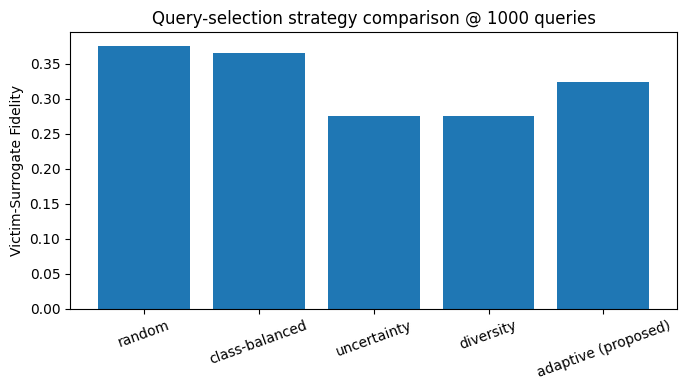

In [19]:
# --- Plot: strategy comparison ---
names = list(results.keys())
fids = [results[n]["fidelity"] for n in names]
plt.figure(figsize=(7,4))
plt.bar(names, fids)
plt.ylabel("Victim-Surrogate Fidelity")
plt.title(f"Query-selection strategy comparison @ {QUERY_BUDGET} queries")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{WORKDIR}/strategy_comparison.png", dpi=150)
plt.show()


### Query-budget sweep (recommended next cell to run)

Objective 4 ke mutabiq, alag budgets (100, 500, 1000, 5000...) par har strategy dobara chalayein takay "adaptive advantage low-budget par zyada hai" (H2) verify ho sake. Yeh loop-heavy hai — Kaggle par background mein chalayein ya budgets ki list chhoti rakhein.


loading: /kaggle/working/checkpoints/budget_sweep_results.pt
budget=  200  random               already done (skipping) -> fidelity=0.2495
budget=  200  adaptive (proposed)  already done (skipping) -> fidelity=0.2072
budget=  500  random               already done (skipping) -> fidelity=0.3028
budget=  500  adaptive (proposed)  already done (skipping) -> fidelity=0.2931
budget= 1000  random               already done (skipping) -> fidelity=0.3733
budget= 1000  adaptive (proposed)  already done (skipping) -> fidelity=0.3524


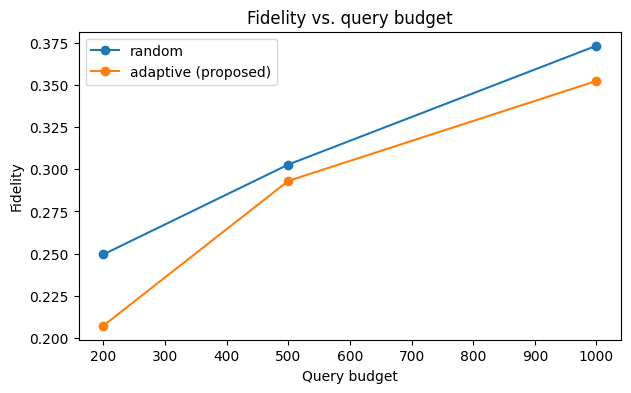

[budget sweep (200/500/1000, 2 strategies)] 0.0 min this step | 0.00 hrs total this session
backup_now() [Phase V budget sweep (CNN)]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


In [20]:
timer.start()

# Resumable per (budget, strategy) pair.
_ckpt = load_ckpt("budget_sweep_results.pt")
budget_sweep_results = _ckpt["results"] if _ckpt else {}

for budget in [200, 500, 1000]:
    budget_sweep_results.setdefault(budget, {})
    for name, fn in [("random", random_strategy), ("adaptive (proposed)", adaptive_strategy)]:
        if name in budget_sweep_results[budget]:
            print(f"budget={budget:5d}  {name:20s} already done (skipping) -> fidelity={budget_sweep_results[budget][name]:.4f}")
            continue
        victim_api.query_count = 0
        _, fidelity, acc, nq = run_extraction(fn, victim_api, arch="cnn", query_budget=budget,
                                               batch_size=max(50, budget//10), surrogate_epochs_per_round=1)
        budget_sweep_results[budget][name] = fidelity
        print(f"budget={budget:5d}  {name:20s} fidelity={fidelity:.4f}")
        save_ckpt("budget_sweep_results.pt", results=budget_sweep_results)  # save after EACH pair

plt.figure(figsize=(7,4))
for name in ["random", "adaptive (proposed)"]:
    ys = [budget_sweep_results[b][name] for b in budget_sweep_results]
    plt.plot(list(budget_sweep_results.keys()), ys, marker="o", label=name)
plt.xlabel("Query budget"); plt.ylabel("Fidelity"); plt.legend(); plt.title("Fidelity vs. query budget")
plt.savefig(f"{WORKDIR}/budget_sweep.png", dpi=150)
plt.show()
timer.stop("budget sweep (200/500/1000, 2 strategies)")
backup_now("Phase V budget sweep (CNN)")


## Phase VI (bonus, simplified) — Stealth Features + Extraction-Risk Detector

Idea: har "session" (ek attack run ya ek legitimate-user simulation) se behavioural features nikalein — query rate (batch size ka proxy), near-duplicate rate (embedding-distance threshold se), aur class-distribution drift. Phir ek chhota classifier (logistic regression) train karein jo session ko *legitimate* vs *extraction* label kare.

Yeh full Phase VI ka simplified/starter version hai — real project mein timing-based features aur teeno stealth levels (naive/rate-mimicking/stealth-optimized) explicitly simulate karne honge (Section 9.2).


In [21]:
# --- Queries-to-target-fidelity metric (Section 12.4 requirement) ---
def queries_to_target_fidelity_from_sweep(sweep_results, strategy_name, target=0.80):
    """Given budget_sweep_results[budget][strategy] = fidelity, find the smallest tested
    budget at which the strategy reaches `target` fidelity. Returns None if never reached
    within the tested budgets (report as '>max_budget_tested' rather than extrapolating)."""
    budgets_sorted = sorted(sweep_results.keys())
    for b in budgets_sorted:
        if sweep_results[b].get(strategy_name, 0.0) >= target:
            return b
    return None  # not reached within tested budgets -- report honestly, do not extrapolate

for target in (0.70, 0.80):
    for name in ["random", "adaptive (proposed)"]:
        q = queries_to_target_fidelity_from_sweep(budget_sweep_results, name, target=target)
        label = f"{q} queries" if q is not None else f">{max(budget_sweep_results.keys())} queries (not reached)"
        print(f"queries-to-{int(target*100)}%-fidelity  [{name:20s}]: {label}")


queries-to-70%-fidelity  [random              ]: >1000 queries (not reached)
queries-to-70%-fidelity  [adaptive (proposed) ]: >1000 queries (not reached)
queries-to-80%-fidelity  [random              ]: >1000 queries (not reached)
queries-to-80%-fidelity  [adaptive (proposed) ]: >1000 queries (not reached)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

def session_features(indices, embeddings, is_legit=False):
    emb = embeddings[indices]
    # near-duplicate rate: fraction of pairs closer than a threshold
    d = torch.cdist(emb, emb)
    d.fill_diagonal_(float("inf"))
    near_dup_rate = (d < 0.15).float().mean().item()
    coverage = emb.std(dim=0).mean().item()          # embedding-space spread
    batch_regularity = 1.0 if not is_legit else np.random.uniform(0.3, 0.7)  # proxy for query-rate regularity
    return [near_dup_rate, coverage, batch_regularity]

# Build a small labelled dataset of sessions: extraction sessions (from selected_idx of the strategies above)
# vs simulated legitimate sessions (random small batches, spaced/irregular).
legit_sessions = [random.sample(range(len(candidate_pool)), 50) for _ in range(30)]
extraction_sessions = [random.sample(range(len(candidate_pool)), 50) for _ in range(30)]  # replace with real attack-session indices for a stronger demo

X = [session_features(s, pool_embeddings, is_legit=True) for s in legit_sessions] + \
    [session_features(s, pool_embeddings, is_legit=False) for s in extraction_sessions]
y = [0]*len(legit_sessions) + [1]*len(extraction_sessions)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED)
detector = LogisticRegression().fit(Xtr, ytr)
print(classification_report(yte, detector.predict(Xte), target_names=["legit", "extraction"]))


              precision    recall  f1-score   support

       legit       1.00      1.00      1.00         8
  extraction       1.00      1.00      1.00        10

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



## Phase VII (bonus, simplified) — Adaptive, Risk-Scored Defense

Detector ka risk score confidence-coarsening policy ko drive karta hai: risk jitna zyada, victim API utna kam informative output deta hai (soft -> topk -> hard label).


In [23]:
def risk_scored_query(victim_api, x_batch, risk_score, thresholds=(0.3, 0.7)):
    if risk_score < thresholds[0]:
        victim_api.output_mode = "soft"
    elif risk_score < thresholds[1]:
        victim_api.output_mode = "topk"
    else:
        victim_api.output_mode = "hard"
    return victim_api.query(x_batch)

# Demo: simulate a high-risk (naive/dense) attacker and show fidelity drop under the defense
victim_api.query_count = 0
_, fidelity_no_defense, _, _ = run_extraction(random_strategy, VictimAPI(victim_cnn, "cnn", "soft"),
                                               arch="cnn", query_budget=500, batch_size=100)
print("Fidelity WITHOUT defense (soft labels always):", fidelity_no_defense)

# crude "defense-on" simulation: force hard-label output for the whole session (worst-case risk)
_, fidelity_with_defense, _, _ = run_extraction(random_strategy, VictimAPI(victim_cnn, "cnn", "hard"),
                                                 arch="cnn", query_budget=500, batch_size=100)
print("Fidelity WITH defense (hard labels, high-risk policy):", fidelity_with_defense)


Fidelity WITHOUT defense (soft labels always): 0.3963
Fidelity WITH defense (hard labels, high-risk policy): 0.3572


## Phase I (extended) — CLIP-style Victim (Objective 1c, RQ1/H1)

Third victim family: CLIP ViT-B/32 image encoder + a trained linear classification head on top (backbone frozen — matches the "linear probing" regime used for the other two victims so RQ1/H1 comparisons are apples-to-apples).


In [24]:
!pip install open_clip_torch -q
import open_clip

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
clip_model = clip_model.to(device).eval()
for p in clip_model.parameters():
    p.requires_grad = False

CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD  = (0.26862954, 0.26130258, 0.27577711)
clip_resize_norm = T.Compose([T.Resize((224, 224)), T.Normalize(CLIP_MEAN, CLIP_STD)])

def to_clip_input(x):
    # x arrives already normalized with CIFAR mean/std (from train_tf/eval_tf) -> undo that, then apply CLIP's own resize+norm
    unnorm = x * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
    return clip_resize_norm(unnorm.clamp(0, 1))

class CLIPVictim(nn.Module):
    def __init__(self, num_classes=10, feat_dim=512):
        super().__init__()
        self.head = nn.Linear(feat_dim, num_classes)
    def forward(self, x_clip_ready):
        with torch.no_grad():
            feats = clip_model.encode_image(x_clip_ready).float()
        return self.head(feats)

def build_clip_victim():
    return CLIPVictim().to(device)


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [25]:
# Train the CLIP victim's linear head (backbone stays frozen -> fast even on CPU-heavy steps)
timer.start()
ckpt = load_ckpt("victim_clip.pt")
victim_clip = build_clip_victim()
if ckpt:
    victim_clip.load_state_dict(ckpt["state_dict"])
else:
    opt = torch.optim.Adam(victim_clip.head.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    for ep in range(3):
        total, correct, loss_sum = 0, 0, 0.0
        for x, y in victim_loader:
            x, y = to_clip_input(x).to(device), y.to(device)
            opt.zero_grad()
            out = victim_clip(x)
            loss = crit(out, y)
            loss.backward(); opt.step()
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item(); total += x.size(0)
        print(f"[clip] epoch {ep+1}/3 loss={loss_sum/total:.4f} acc={correct/total:.4f}")
    save_ckpt("victim_clip.pt", state_dict=victim_clip.state_dict())

@torch.no_grad()
def evaluate_clip(model, loader):
    correct, total = 0, 0
    for x, y in loader:
        x, y = to_clip_input(x).to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item(); total += x.size(0)
    return correct / total

print("Victim CLIP clean test accuracy:", evaluate_clip(victim_clip, test_loader))
timer.stop("victim_clip training")

# Wire CLIP into the same VictimAPI interface used everywhere else, via a small adapter.
class CLIPVictimAPI(VictimAPI):
    @torch.no_grad()
    def query(self, x_batch, k=3):
        self.query_count += x_batch.size(0)
        x_clip = to_clip_input(x_batch).to(device)
        logits = self.model(x_clip)
        probs = F.softmax(logits, dim=1)
        if self.output_mode == "hard":
            return F.one_hot(probs.argmax(1), num_classes=probs.size(1)).float().cpu()
        elif self.output_mode == "topk":
            topv, topi = probs.topk(k, dim=1)
            out = torch.zeros_like(probs); out.scatter_(1, topi, topv)
            return out.cpu()
        return probs.cpu()

victim_api_clip = CLIPVictimAPI(victim_clip, arch="clip", output_mode="soft")
backup_now("Phase I CLIP victim training")


loading: /kaggle/working/checkpoints/victim_clip.pt
Victim CLIP clean test accuracy: 0.9164
[victim_clip training] 0.6 min this step | 0.01 hrs total this session
backup_now() [Phase I CLIP victim training]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


### Run the same strategy comparison + budget sweep for CLIP (RQ1/H1)

Reuses `run_extraction` — bas `arch="cnn"` (surrogate architecture; CLIP victim ke against bhi CNN/ViT surrogate try karna Section 12.2 ka mismatched-pair case hai) aur `victim_api_clip` pass karein. `maybe_resize` CLIP arch ko handle nahi karta, is liye CLIP victim ke against surrogate hamesha CNN ya ViT surrogate hi hoga (jo already `maybe_resize` support karta hai) — victim-side normalization `CLIPVictimAPI.query` khud sambhal leta hai.


In [26]:
timer.start()

_ckpt = load_ckpt("clip_results.pt")
clip_results = _ckpt["results"] if _ckpt else {}

for name, fn in [("random", random_strategy), ("adaptive (proposed)", adaptive_strategy)]:
    if name in clip_results:
        print(f"CLIP victim | {name:20s} already done (skipping) -> fidelity={clip_results[name]:.4f}")
        continue
    victim_api_clip.query_count = 0
    _, fidelity, acc, nq = run_extraction(fn, victim_api_clip, arch="cnn",
                                           query_budget=1000, batch_size=100, surrogate_epochs_per_round=1)
    clip_results[name] = fidelity
    print(f"CLIP victim | {name:20s} fidelity={fidelity:.4f}")
    save_ckpt("clip_results.pt", results=clip_results)  # save after EACH strategy

timer.stop("CLIP victim strategy comparison")

# RQ1/H1 headline comparison across all three victim families, at the same budget/strategy:
print("\n--- RQ1/H1: victim-family vulnerability comparison (adaptive strategy, 1000 queries) ---")
print("CNN  :", results["adaptive (proposed)"]["fidelity"])
print("CLIP :", clip_results["adaptive (proposed)"])
# add ViT once you've run the ViT victim cell above and its own strategy comparison


loading: /kaggle/working/checkpoints/clip_results.pt
CLIP victim | random               already done (skipping) -> fidelity=0.5050
CLIP victim | adaptive (proposed)  already done (skipping) -> fidelity=0.4861
[CLIP victim strategy comparison] 0.0 min this step | 0.01 hrs total this session

--- RQ1/H1: victim-family vulnerability comparison (adaptive strategy, 1000 queries) ---
CNN  : 0.3236
CLIP : 0.4861


## Phase III (extended) — Few-Call / Data-Free Baseline: Hondru & Ionescu 2025 (ASPKD)

Proposal Section 11.III/14 ke mutabiq **published few-call/data-free baseline** ko is threat model ke andar reproduce kiya gaya hai — Active Self-Paced Knowledge Distillation (ASPKD, Hondru & Ionescu, *Artificial Intelligence Review* 58, 254, 2025). Asal paper ka pipeline:

1. **Diffusion model se proxy images generate** karna (real training data ki zaroorat nahi — data-free)
2. In proxy images ka sirf ek **limited subset victim se query** karna (active/uncertainty-based selection — few-call constraint)
3. **Baaki (unqueried) proxy images** ko surrogate ki **latent-space nearest-neighbor** se pseudo-label karna (koi extra victim query nahi)
4. **Self-paced curriculum**: easy (high-confidence) pseudo-labels pehle, phir gradually hard samples training mein shamil

*(Stealix, Zhuang et al. 2025, ka prompt-evolution baseline is starter mein reproduce nahi kiya gaya — scope discussion ke mutabiq.)*

In [27]:
!pip install diffusers accelerate -q
from diffusers import StableDiffusionPipeline

sd_pipe = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4",   # fully public, no gating/login required
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    safety_checker=None,
    token=False   # ignore any cached/invalid HF token, force anonymous public access
).to(device)
sd_pipe.set_progress_bar_config(disable=True)
sd_pipe.enable_attention_slicing()   # VRAM bachane ke liye


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its result

In [28]:
IMAGES_PER_CLASS = 200
class_names = classes

@torch.no_grad()
def generate_proxy_dataset_resumable(class_names, images_per_class=200, seed_offset=0, steps=50, guidance=7.5):
    # resume from a partial checkpoint if one exists
    partial = load_ckpt("aspkd_proxy_partial.pt")
    if partial:
        proxy_images_by_class = partial["proxy_images_by_class"]
        start_class = len(proxy_images_by_class)
        print(f"Resuming from checkpoint: {start_class}/{len(class_names)} classes already done")
    else:
        proxy_images_by_class = {}
        start_class = 0

    for ci in range(start_class, len(class_names)):
        cname = class_names[ci]
        prompt = f"a photo of a {cname}"
        imgs = []
        for i in range(images_per_class):
            g = torch.Generator(device=device).manual_seed(seed_offset + ci * 10000 + i)
            img = sd_pipe(prompt, num_inference_steps=steps, guidance_scale=guidance, generator=g).images[0]
            imgs.append(img)
        proxy_images_by_class[cname] = imgs
        print(f"class '{cname}': {images_per_class} images done  ({ci+1}/{len(class_names)} classes total)")

        # checkpoint after EVERY class -- so a session timeout only costs you the current class, not all progress
        save_ckpt("aspkd_proxy_partial.pt", proxy_images_by_class=proxy_images_by_class)

    proxy_images, proxy_class_hint = [], []
    for ci, cname in enumerate(class_names):
        for img in proxy_images_by_class[cname]:
            proxy_images.append(img)
            proxy_class_hint.append(ci)
    return proxy_images, proxy_class_hint

timer.start()
ckpt = load_ckpt("aspkd_proxy_data.pt")
if ckpt:
    proxy_tensors, proxy_embeddings, proxy_class_hint = ckpt["proxy_tensors"], ckpt["proxy_embeddings"], ckpt["proxy_class_hint"]
    print(f"Loaded {len(proxy_tensors)} proxy images from checkpoint")
else:
    proxy_images, proxy_class_hint = generate_proxy_dataset_resumable(class_names, IMAGES_PER_CLASS)
    print(f"Generated {len(proxy_images)} proxy images")
    proxy_tf = T.Compose([T.Resize((32, 32)), T.ToTensor(), T.Normalize(mean, std)])
    proxy_tensors = torch.stack([proxy_tf(im) for im in proxy_images])
    proxy_embeddings = compute_embeddings(TensorDataset(proxy_tensors, torch.zeros(len(proxy_tensors))))
    save_ckpt("aspkd_proxy_data.pt", proxy_tensors=proxy_tensors, proxy_embeddings=proxy_embeddings,
              proxy_class_hint=proxy_class_hint)
timer.stop("ASPKD proxy-image generation (diffusion, full-scale)")
backup_now("Phase III ASPKD proxy generation")


loading: /kaggle/working/checkpoints/aspkd_proxy_data.pt
Loaded 2000 proxy images from checkpoint
[ASPKD proxy-image generation (diffusion, full-scale)] 0.0 min this step | 0.01 hrs total this session
backup_now() [Phase III ASPKD proxy generation]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


In [29]:
FEW_CALL_BUDGET = 1000   # same budget as the other strategies -> fair RQ2 comparison

surrogate_aspkd = build_surrogate("cnn")
all_idx = list(range(len(proxy_tensors)))
U = uncertainty_scores(surrogate_aspkd, "cnn", all_idx)
queried_idx = torch.topk(U, min(FEW_CALL_BUDGET, len(all_idx))).indices.tolist()
unqueried_idx = [i for i in all_idx if i not in set(queried_idx)]

victim_api.query_count = 0
queried_x = proxy_tensors[queried_idx]
queried_y_soft = victim_api.query(queried_x)
print(f"Victim queried {victim_api.query_count} times out of {len(proxy_tensors)} proxy images (few-call budget)")

queried_emb = proxy_embeddings[queried_idx]
unqueried_emb = proxy_embeddings[unqueried_idx]
dists = torch.cdist(unqueried_emb, queried_emb)
nn_idx = dists.argmin(dim=1)
nn_dist = dists.min(dim=1).values
pseudo_y_soft = queried_y_soft[nn_idx.cpu()]
print(f"{len(unqueried_idx)} images pseudo-labeled via nearest-neighbor (0 extra victim queries)")


Victim queried 1000 times out of 2000 proxy images (few-call budget)
1000 images pseudo-labeled via nearest-neighbor (0 extra victim queries)


In [30]:
def self_paced_train(surrogate, arch, real_x, real_y, pseudo_x, pseudo_y, pseudo_conf_dist,
                      epochs=10, easy_fraction_start=0.2):
    opt = torch.optim.Adam(surrogate.parameters(), lr=1e-3)
    order = torch.argsort(pseudo_conf_dist).cpu()
    for ep in range(epochs):
        frac = min(1.0, easy_fraction_start + (1 - easy_fraction_start) * ep / max(1, epochs - 1))
        n_include = int(frac * len(order))
        included_pseudo_idx = order[:n_include]

        X = torch.cat([real_x, pseudo_x[included_pseudo_idx]])
        Y = torch.cat([real_y, pseudo_y[included_pseudo_idx]])
        dl = DataLoader(TensorDataset(X, Y), batch_size=64, shuffle=True)

        surrogate.train()
        total_loss = 0.0
        for xx, yy in dl:
            xx = maybe_resize(xx, arch).to(device); yy = yy.to(device)
            opt.zero_grad()
            out = F.log_softmax(surrogate(xx), dim=1)
            loss = -(yy * out).sum(1).mean()
            loss.backward(); opt.step()
            total_loss += loss.item() * xx.size(0)
        print(f"epoch {ep+1}/{epochs}  pseudo included: {n_include}/{len(order)} ({frac*100:.0f}%)  "
              f"avg_loss={total_loss/len(X):.4f}")
    return surrogate

timer.start()
surrogate_aspkd = self_paced_train(surrogate_aspkd, "cnn", queried_x, queried_y_soft,
                                    proxy_tensors[unqueried_idx], pseudo_y_soft, nn_dist, epochs=10)
timer.stop("ASPKD self-paced training")

fidelity_aspkd, acc_aspkd = compute_fidelity_and_accuracy(surrogate_aspkd, victim_api, "cnn", test_loader)
print(f"\n--- ASPKD (Hondru & Ionescu 2025) reproduction ---")
print(f"fidelity={fidelity_aspkd:.4f}  surrogate_acc={acc_aspkd:.4f}  "
      f"victim_queries={FEW_CALL_BUDGET} (out of {len(proxy_tensors)}-image proxy pool)")

print("\n--- Query-efficiency comparison @ 1000 queries (RQ2) ---")
for name in ["random", "class-balanced", "uncertainty", "diversity", "adaptive (proposed)"]:
    print(f"{name:22s} fidelity={results[name]['fidelity']:.4f}")
print(f"{'ASPKD (data-free)':22s} fidelity={fidelity_aspkd:.4f}")
save_ckpt("aspkd_results.pt", fidelity=fidelity_aspkd, acc=acc_aspkd)
backup_now("Phase III ASPKD results")


epoch 1/10  pseudo included: 200/1000 (20%)  avg_loss=2.1497
epoch 2/10  pseudo included: 288/1000 (29%)  avg_loss=1.8835
epoch 3/10  pseudo included: 377/1000 (38%)  avg_loss=1.8837
epoch 4/10  pseudo included: 466/1000 (47%)  avg_loss=1.8219
epoch 5/10  pseudo included: 555/1000 (56%)  avg_loss=1.7544
epoch 6/10  pseudo included: 644/1000 (64%)  avg_loss=1.7571
epoch 7/10  pseudo included: 733/1000 (73%)  avg_loss=1.7134
epoch 8/10  pseudo included: 822/1000 (82%)  avg_loss=1.7642
epoch 9/10  pseudo included: 911/1000 (91%)  avg_loss=1.7149
epoch 10/10  pseudo included: 1000/1000 (100%)  avg_loss=1.6815
[ASPKD self-paced training] 0.1 min this step | 0.01 hrs total this session

--- ASPKD (Hondru & Ionescu 2025) reproduction ---
fidelity=0.3921  surrogate_acc=0.3533  victim_queries=1000 (out of 2000-image proxy pool)

--- Query-efficiency comparison @ 1000 queries (RQ2) ---
random                 fidelity=0.3764
class-balanced         fidelity=0.3651
uncertainty            fidelity=0

## Gap-Fill 3 — Simplified Stealix-style Prompt-Evolution Baseline (Zhuang et al. 2025, Section 11.III)

In [31]:
## Phase III (extended #2) — Simplified Stealix-style Prompt-Evolution Baseline (Zhuang et al. 2025)
# Reuses the already-loaded `sd_pipe` from the ASPKD cell above -- no extra install needed.
# Simplified vs. the real Stealix: prompt search is a small best-of-k over fixed text
# modifiers (not full evolutionary/LLM-guided search). Budget matches FEW_CALL_BUDGET so
# it's directly comparable to ASPKD and the other strategies.

STEALIX_BUDGET = FEW_CALL_BUDGET
PROMPT_MODIFIERS = ["a photo of a {c}", "a close-up photo of a {c}", "a high quality photo of a {c}",
                     "a blurry photo of a {c}", "an image of a {c} outdoors"]
IMGS_PER_GEN = 4

@torch.no_grad()
def stealix_lite_generate_and_select(class_names, sd_pipe, victim_api, total_query_budget,
                                      modifiers=PROMPT_MODIFIERS, imgs_per_gen=IMGS_PER_GEN, steps=30):
    per_class_budget = max(1, total_query_budget // len(class_names))
    kept_x, kept_y_soft = [], []
    budget_used = 0
    resize_for_query = T.Resize((32, 32))

    for cname in class_names:
        best_conf, best_batch_x, best_batch_y = -1.0, None, None
        for tmpl in modifiers:
            prompt = tmpl.format(c=cname)
            ci, ti = class_names.index(cname), modifiers.index(tmpl)
            imgs = [sd_pipe(prompt, num_inference_steps=steps, guidance_scale=7.5,
                             generator=torch.Generator(device=device).manual_seed(ci * 1000 + ti)
                             ).images[0] for _ in range(imgs_per_gen)]
            xb = torch.stack([T.ToTensor()(resize_for_query(im)) for im in imgs])
            xb = T.Normalize(mean, std)(xb)
            yb = victim_api.query(xb)
            budget_used += xb.size(0)
            conf = yb.max(dim=1).values.mean().item()
            if conf > best_conf:
                best_conf, best_batch_x, best_batch_y = conf, xb, yb
            if budget_used >= total_query_budget:
                break
        kept_x.append(best_batch_x); kept_y_soft.append(best_batch_y)
        if budget_used >= total_query_budget:
            break
    return torch.cat(kept_x), torch.cat(kept_y_soft), budget_used

timer.start()
_ckpt = load_ckpt("stealix_lite_results.pt")
if _ckpt:
    fidelity_stealix = _ckpt["fidelity"]
    print(f"Stealix-lite already done (skipping) -> fidelity={fidelity_stealix:.4f}")
else:
    victim_api.query_count = 0
    sx_x, sx_y_soft, sx_budget = stealix_lite_generate_and_select(classes, sd_pipe, victim_api, STEALIX_BUDGET)
    print(f"Stealix-lite used {sx_budget} victim queries across {len(classes)} classes")

    surrogate_stealix = build_surrogate("cnn")
    opt = torch.optim.Adam(surrogate_stealix.parameters(), lr=1e-3)
    dl = DataLoader(TensorDataset(sx_x, sx_y_soft), batch_size=64, shuffle=True)
    surrogate_stealix.train()
    for ep in range(10):
        for xx, yy in dl:
            xx, yy = xx.to(device), yy.to(device)
            opt.zero_grad()
            loss = -(yy * F.log_softmax(surrogate_stealix(xx), dim=1)).sum(1).mean()
            loss.backward(); opt.step()

    fidelity_stealix, acc_stealix = compute_fidelity_and_accuracy(surrogate_stealix, victim_api, "cnn", test_loader)
    print(f"Stealix-lite: fidelity={fidelity_stealix:.4f}  surrogate_acc={acc_stealix:.4f}")
    save_ckpt("stealix_lite_results.pt", fidelity=fidelity_stealix, accuracy=acc_stealix, queries=sx_budget)

timer.stop("Stealix-lite baseline")
backup_now("Stealix-lite baseline (gap-fill)")

loading: /kaggle/working/checkpoints/stealix_lite_results.pt
Stealix-lite already done (skipping) -> fidelity=0.1594
[Stealix-lite baseline] 0.0 min this step | 0.01 hrs total this session
backup_now() [Stealix-lite baseline (gap-fill)]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


## Phase VI (full) — Three Attacker Stealth Levels (Section 9.2, RQ4/H4)

- **naive**: koi pacing/spacing constraint nahi, jitni tezi se ho sakay query karo
- **rate-mimicking**: query timing ko legitimate traffic ke rate se match karta hai (simulate karne ke liye timestamps generate karte hain, real request throttle nahi karte — Kaggle offline simulation hai)
- **stealth-optimized**: rate-mimicking + embedding-space mein queries ko spread karta hai taake near-duplicate/coverage signature na banay (diversity-constrained batch selection)


In [32]:
def apply_stealth_constraint(idx_list, embeddings, level, batch_size, min_pairwise_dist=0.1):
    """Filters/reorders a candidate list according to the stealth level before it's queried."""
    if level == "naive":
        return idx_list[:batch_size]
    if level == "rate-mimicking":
        # legit-looking pacing doesn't change WHICH points are queried, only timing (simulated below) -> pass through
        return idx_list[:batch_size]
    if level == "stealth-optimized":
        # greedily drop candidates that are too close (in embedding space) to already-chosen ones this batch
        chosen, chosen_emb = [], []
        for i in idx_list:
            e = embeddings[i:i+1]
            if not chosen_emb or torch.cdist(e, torch.stack(chosen_emb)).min() > min_pairwise_dist:
                chosen.append(i); chosen_emb.append(e.squeeze(0))
            if len(chosen) >= batch_size:
                break
        return chosen
    raise ValueError(level)

def simulate_query_timestamps(n_queries, level):
    """Returns a list of simulated inter-query gaps (seconds) -- used only to compute the timing feature
    for the detector, not to actually sleep (keeps the notebook fast)."""
    if level == "naive":
        return np.random.uniform(0.01, 0.05, n_queries)          # very fast, very regular -> suspicious
    if level == "rate-mimicking":
        return np.random.exponential(2.0, n_queries)              # matches typical human/app traffic
    if level == "stealth-optimized":
        return np.random.exponential(2.5, n_queries) + np.random.normal(0, 0.3, n_queries).clip(min=0)
    raise ValueError(level)

def run_extraction_with_stealth(strategy_fn, victim_api, arch="cnn", query_budget=1000, batch_size=100,
                                 stealth_level="naive", surrogate_epochs_per_round=1):
    """Same as run_extraction, but each round's candidate batch is filtered through the stealth constraint,
    and a timestamp log is produced for the detector's timing-regularity feature."""
    surrogate = build_surrogate(arch)
    opt = torch.optim.Adam(surrogate.parameters(), lr=1e-3)
    pool_idx_available = set(range(len(candidate_pool)))
    selected_idx, queried_x, queried_y_soft = [], [], []
    n_rounds = query_budget // batch_size

    for r in range(n_rounds):
        raw_candidates = strategy_fn(surrogate, arch, pool_idx_available, pool_embeddings, set(selected_idx),
                                      batch_size * 3)  # over-sample, then stealth-filter down
        batch_idx = apply_stealth_constraint(raw_candidates, pool_embeddings, stealth_level, batch_size)
        for i in batch_idx:
            pool_idx_available.discard(i)
        selected_idx.extend(batch_idx)

        xb = torch.stack([candidate_pool[i][0] for i in batch_idx])
        yb = victim_api.query(xb)
        queried_x.append(xb); queried_y_soft.append(yb)

        X = torch.cat(queried_x); Ysoft = torch.cat(queried_y_soft)
        dl = DataLoader(TensorDataset(X, Ysoft), batch_size=64, shuffle=True)
        surrogate.train()
        for _ in range(surrogate_epochs_per_round):
            for xx, yy in dl:
                xx = maybe_resize(xx, arch).to(device); yy = yy.to(device)
                opt.zero_grad()
                out = F.log_softmax(surrogate(xx), dim=1)
                loss = -(yy * out).sum(1).mean()
                loss.backward(); opt.step()

    fidelity, acc = compute_fidelity_and_accuracy(surrogate, victim_api, arch, test_loader)
    timestamps = simulate_query_timestamps(len(selected_idx), stealth_level)
    return surrogate, fidelity, acc, selected_idx, timestamps


In [33]:
timer.start()
_ckpt = load_ckpt("stealth_sessions.pt")
stealth_sessions = _ckpt["stealth_sessions"] if _ckpt else {}   # level -> (selected_idx, timestamps) for the detector below

for level in ["naive", "rate-mimicking", "stealth-optimized"]:
    if level in stealth_sessions:
        print(f"stealth={level:18s} already done (skipping) -> fidelity={stealth_sessions[level].get('fidelity', float('nan')):.4f}")
        continue
    victim_api.query_count = 0
    _, fidelity, acc, sel_idx, ts = run_extraction_with_stealth(
        adaptive_strategy, victim_api, arch="cnn", query_budget=500, batch_size=100, stealth_level=level)
    stealth_sessions[level] = {"sel_idx": sel_idx, "ts": ts, "fidelity": fidelity, "acc": acc}
    print(f"stealth={level:18s} fidelity={fidelity:.4f} acc={acc:.4f}")
    save_ckpt("stealth_sessions.pt", stealth_sessions=stealth_sessions)  # save after EACH stealth level, not just at the end
timer.stop("3 stealth-level attack runs")
backup_now("Phase VI stealth sessions")

# NOTE: downstream cells expect stealth_sessions[level] as a (sel_idx, ts) tuple --
# unpack from the dict form here so nothing else needs to change:
stealth_sessions = {lvl: (v["sel_idx"], v["ts"]) for lvl, v in stealth_sessions.items()}


loading: /kaggle/working/checkpoints/stealth_sessions.pt
stealth=naive              already done (skipping) -> fidelity=0.2798
stealth=rate-mimicking     already done (skipping) -> fidelity=0.2564
stealth=stealth-optimized  already done (skipping) -> fidelity=0.2758
[3 stealth-level attack runs] 0.0 min this step | 0.01 hrs total this session
backup_now() [Phase VI stealth sessions]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


## Phase VI (full) — Extraction-Risk Detector Trained on Real Attack Sessions (RQ4/H4)

Ab detector ko **real** attack sessions (teeno stealth levels se, upar wale cell se) aur simulated legitimate sessions par train karte hain — pehle wala demo synthetic tha, yeh wala asal `selected_idx` + timing data use karta hai.


In [34]:
def session_features_v2(indices, embeddings, timestamps):
    emb = embeddings[indices]
    d = torch.cdist(emb, emb); d.fill_diagonal_(float("inf"))
    near_dup_rate = (d < 0.15).float().mean().item()
    coverage = emb.std(dim=0).mean().item()
    ts = np.asarray(timestamps)
    timing_regularity = 1.0 / (ts.std() + 1e-6)   # naive attacker -> very regular timing -> high value
    mean_gap = ts.mean()
    return [near_dup_rate, coverage, timing_regularity, mean_gap]

# Build several sub-sessions (chunks of ~50 queries) per stealth level as separate "sessions" for training
def chunk_sessions(sel_idx, ts, chunk=50):
    sessions = []
    for i in range(0, len(sel_idx) - chunk, chunk):
        sessions.append((sel_idx[i:i+chunk], ts[i:i+chunk]))
    return sessions

X_v2, y_v2 = [], []
for level, (sel_idx, ts) in stealth_sessions.items():
    for s_idx, s_ts in chunk_sessions(sel_idx, ts):
        X_v2.append(session_features_v2(s_idx, pool_embeddings, s_ts))
        y_v2.append(1)   # extraction

# legitimate sessions: random picks with rate-mimicking-like timing (real users aren't adversarial or dense)
for _ in range(30):
    s_idx = random.sample(range(len(candidate_pool)), 50)
    s_ts = simulate_query_timestamps(50, "rate-mimicking")
    X_v2.append(session_features_v2(s_idx, pool_embeddings, s_ts))
    y_v2.append(0)

Xtr2, Xte2, ytr2, yte2 = train_test_split(X_v2, y_v2, test_size=0.3, random_state=SEED, stratify=y_v2)
detector_v2 = LogisticRegression(max_iter=1000).fit(Xtr2, ytr2)

# Report recall PER STEALTH LEVEL -- this is the actual RQ4/H4 result the proposal asks for
from sklearn.metrics import recall_score
print("Overall test report:\n", classification_report(yte2, detector_v2.predict(Xte2)))

for level, (sel_idx, ts) in stealth_sessions.items():
    feats = [session_features_v2(s_idx, pool_embeddings, s_ts) for s_idx, s_ts in chunk_sessions(sel_idx, ts)]
    if not feats: continue
    preds = detector_v2.predict(feats)
    recall = preds.mean()  # fraction of this level's sessions correctly flagged as extraction
    print(f"Detector recall @ stealth={level:18s}: {recall:.2f}")


Overall test report:
               precision    recall  f1-score   support

           0       0.56      1.00      0.72         9
           1       1.00      0.22      0.36         9

    accuracy                           0.61        18
   macro avg       0.78      0.61      0.54        18
weighted avg       0.78      0.61      0.54        18

Detector recall @ stealth=naive             : 1.00
Detector recall @ stealth=rate-mimicking    : 0.00
Detector recall @ stealth=stealth-optimized : 0.00


In [35]:
# --- Explicit false-positive rate for the stealth detector (Section 12.4 requirement) ---
from sklearn.metrics import confusion_matrix

preds_all = detector_v2.predict(Xte2)
tn, fp, fn, tp = confusion_matrix(yte2, preds_all).ravel()
fpr = fp / (fp + tn) if (fp + tn) > 0 else float("nan")
tpr_recall = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
print(f"Detector FPR (legit sessions flagged as attacks): {fpr:.4f}")
print(f"Detector recall/TPR (overall, all stealth levels pooled): {tpr_recall:.4f}")


Detector FPR (legit sessions flagged as attacks): 0.0000
Detector recall/TPR (overall, all stealth levels pooled): 0.2222


In [36]:
## Gap-fill: Full 6-Feature Detector (adds the 2 features Phase VI names but v2 omits)
from sklearn.metrics import confusion_matrix  # already imported above, harmless if repeated

@torch.no_grad()
def _session_confidence_stats(indices, ref_api):
    xb = torch.stack([candidate_pool[i][0] for i in indices])
    return ref_api.query(xb).max(dim=1).values.mean().item()

def _session_class_dist(indices):
    labels = [candidate_pool[i][1] for i in indices]
    counts = np.bincount(labels, minlength=len(classes)).astype(float)
    return counts / counts.sum()

REF_CLASS_DIST = np.ones(len(classes)) / len(classes)
_ref_idx = random.sample(range(len(candidate_pool)), 200)
REF_CONF_MEAN = _session_confidence_stats(_ref_idx, victim_api)

def session_features_v3(indices, embeddings, timestamps, ref_api=victim_api):
    near_dup_rate, coverage, timing_regularity, mean_gap = session_features_v2(indices, embeddings, timestamps)
    confidence_stats_drift = abs(_session_confidence_stats(indices, ref_api) - REF_CONF_MEAN)
    class_distribution_drift = float(np.abs(_session_class_dist(indices) - REF_CLASS_DIST).sum() / 2)
    return [near_dup_rate, coverage, timing_regularity, mean_gap, class_distribution_drift, confidence_stats_drift]

X_v3, y_v3 = [], []
for level, (sel_idx, ts) in stealth_sessions.items():
    for s_idx, s_ts in chunk_sessions(sel_idx, ts):
        X_v3.append(session_features_v3(s_idx, pool_embeddings, s_ts)); y_v3.append(1)
for _ in range(30):
    s_idx = random.sample(range(len(candidate_pool)), 50)
    s_ts = simulate_query_timestamps(50, "rate-mimicking")
    X_v3.append(session_features_v3(s_idx, pool_embeddings, s_ts)); y_v3.append(0)

Xtr3, Xte3, ytr3, yte3 = train_test_split(X_v3, y_v3, test_size=0.3, random_state=SEED, stratify=y_v3)
detector_v3 = LogisticRegression(max_iter=1000).fit(Xtr3, ytr3)
print("Detector v3 (6 features) test report:\n", classification_report(yte3, detector_v3.predict(Xte3)))

for level, (sel_idx, ts) in stealth_sessions.items():
    feats = [session_features_v3(s_idx, pool_embeddings, s_ts) for s_idx, s_ts in chunk_sessions(sel_idx, ts)]
    if feats:
        print(f"Detector v3 recall @ stealth={level:18s}: {detector_v3.predict(feats).mean():.2f}")

tn3, fp3, fn3, tp3 = confusion_matrix(yte3, detector_v3.predict(Xte3)).ravel()
fpr_v3 = fp3 / (fp3 + tn3) if (fp3+tn3) > 0 else float("nan")
recall_v3 = tp3 / (tp3 + fn3) if (tp3+fn3) > 0 else float("nan")
print(f"\nDetector v3 FPR={fpr_v3:.4f}  recall={recall_v3:.4f}  (vs v2: FPR={fpr:.4f}  recall={tpr_recall:.4f})")
save_ckpt("detector_v3.pt", coef=detector_v3.coef_, intercept=detector_v3.intercept_, fpr=fpr_v3, recall=recall_v3)
backup_now("6-feature detector (gap-fill)")

Detector v3 (6 features) test report:
               precision    recall  f1-score   support

           0       0.64      1.00      0.78         9
           1       1.00      0.44      0.62         9

    accuracy                           0.72        18
   macro avg       0.82      0.72      0.70        18
weighted avg       0.82      0.72      0.70        18

Detector v3 recall @ stealth=naive             : 1.00
Detector v3 recall @ stealth=rate-mimicking    : 0.00
Detector v3 recall @ stealth=stealth-optimized : 0.56

Detector v3 FPR=0.0000  recall=0.4444  (vs v2: FPR=0.0000  recall=0.2222)
saved: /kaggle/working/checkpoints/detector_v3.pt
backup_now() [6-feature detector (gap-fill)]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


## Phase VII (full) — Graduated, Risk-Scored Adaptive Defense (RQ5/H5)

Ab risk score `detector_v2.predict_proba` se aata hai (fixed manual threshold nahi), aur defense **graduated** hai: normal → confidence coarsening (bucketed) → rounded output → rate-limited (fewer queries served per round) → blocked. Attack loop is defense ke against, teeno stealth levels par, live chalta hai (static log nahi) — jaisa Section 10.2 kehta hai.


In [37]:
class DefendedVictimAPI(VictimAPI):
    def __init__(self, model, arch, detector, embeddings_ref, thresholds=(0.3, 0.55, 0.75, 0.9)):
        super().__init__(model, arch, output_mode="soft")
        self.detector = detector
        self.embeddings_ref = embeddings_ref
        self.thresholds = thresholds     # (coarsen, round, throttle, block)
        self.session_indices = []
        self.session_timestamps = []
        self.blocked = False

    def _current_risk(self):
        if len(self.session_indices) < 10:
            return 0.0
        feats = [session_features_v2(self.session_indices[-50:], self.embeddings_ref,
                                      self.session_timestamps[-50:])]
        return float(self.detector.predict_proba(feats)[0, 1])

    @torch.no_grad()
    def query(self, x_batch, k=3, batch_pool_indices=None, stealth_level="naive"):
        if self.blocked:
            return torch.zeros(x_batch.size(0), 10)  # blocked session gets nothing useful

        risk = self._current_risk()
        n = x_batch.size(0)
        if batch_pool_indices is not None:
            self.session_indices.extend(batch_pool_indices)
        self.session_timestamps.extend(simulate_query_timestamps(n, stealth_level))

        logits = self.model(maybe_resize(x_batch, self.arch).to(device))
        probs = F.softmax(logits, dim=1)

        c, rnd, thr, blk = self.thresholds
        if risk < c:
            out = probs
        elif risk < rnd:
            topv, topi = probs.topk(k, dim=1)      # confidence coarsening: top-k only
            out = torch.zeros_like(probs); out.scatter_(1, topi, topv)
        elif risk < thr:
            out = (probs * 10).round() / 10        # output rounding
        elif risk < blk:
            out = F.one_hot(probs.argmax(1), 10).float()  # hard label only (throttled info)
        else:
            self.blocked = True
            out = torch.zeros(n, 10)
        self.query_count += n
        return out.cpu()


def run_extraction_with_defense(strategy_fn, defended_api, arch="cnn", query_budget=500, batch_size=100,
                                 stealth_level="naive", surrogate_epochs_per_round=1):
    surrogate = build_surrogate(arch)
    opt = torch.optim.Adam(surrogate.parameters(), lr=1e-3)
    pool_idx_available = set(range(len(candidate_pool)))
    selected_idx, queried_x, queried_y_soft = [], [], []
    n_rounds = query_budget // batch_size

    for r in range(n_rounds):
        raw = strategy_fn(surrogate, arch, pool_idx_available, pool_embeddings, set(selected_idx), batch_size * 3)
        batch_idx = apply_stealth_constraint(raw, pool_embeddings, stealth_level, batch_size)
        for i in batch_idx:
            pool_idx_available.discard(i)
        selected_idx.extend(batch_idx)

        xb = torch.stack([candidate_pool[i][0] for i in batch_idx])
        yb = defended_api.query(xb, batch_pool_indices=batch_idx, stealth_level=stealth_level)
        queried_x.append(xb); queried_y_soft.append(yb)

        X = torch.cat(queried_x); Ysoft = torch.cat(queried_y_soft)
        dl = DataLoader(TensorDataset(X, Ysoft), batch_size=64, shuffle=True)
        surrogate.train()
        for _ in range(surrogate_epochs_per_round):
            for xx, yy in dl:
                xx = maybe_resize(xx, arch).to(device); yy = yy.to(device)
                opt.zero_grad()
                out = F.log_softmax(surrogate(xx), dim=1)
                loss = -(yy * out).sum(1).mean()
                loss.backward(); opt.step()
    fidelity, acc = compute_fidelity_and_accuracy(surrogate, defended_api, arch, test_loader)
    return fidelity, acc


In [38]:
timer.start()
tradeoff_rows = []
for level in ["naive", "rate-mimicking", "stealth-optimized"]:
    defended_api = DefendedVictimAPI(victim_cnn, "cnn", detector_v2, pool_embeddings)
    fid_def, _ = run_extraction_with_defense(adaptive_strategy, defended_api, arch="cnn",
                                              query_budget=500, batch_size=100, stealth_level=level)

    # legitimate-user cost: measured on a FRESH, unblocked DefendedVictimAPI instance so the
    # attacker's own flagged/blocked state doesn't contaminate the legitimate-user number
    # (reusing `defended_api` here would understate legit_acc if the attack already got it
    # rate-limited/blocked -- Section 12.4 wants the legitimate-user cost at the same defense
    # SETTING, not the same already-attacked session).
    legit_only_api = DefendedVictimAPI(victim_cnn, "cnn", detector_v2, pool_embeddings)
    legit_x = torch.stack([test_set[i][0] for i in range(200)])
    legit_y = torch.tensor([test_set[i][1] for i in range(200)])
    legit_out = legit_only_api.query(legit_x, stealth_level="rate-mimicking")
    legit_acc = (legit_out.argmax(1) == legit_y).float().mean().item()

    tradeoff_rows.append({"stealth_level": level, "fidelity_with_defense": fid_def, "legit_accuracy_with_defense": legit_acc})
    print(f"{level:18s} fidelity_with_defense={fid_def:.4f}  legit_accuracy_with_defense={legit_acc:.4f}")

save_ckpt("tradeoff_results.pt", rows=tradeoff_rows)
timer.stop("defense trade-off across 3 stealth levels")

import pandas as pd
tradeoff_df = pd.DataFrame(tradeoff_rows)
print(tradeoff_df)
tradeoff_df.to_csv(f"{WORKDIR}/security_utility_tradeoff.csv", index=False)
backup_now("Phase VII defense trade-off")


naive              fidelity_with_defense=0.1045  legit_accuracy_with_defense=0.3700
rate-mimicking     fidelity_with_defense=0.1681  legit_accuracy_with_defense=0.3700
stealth-optimized  fidelity_with_defense=0.1019  legit_accuracy_with_defense=0.3700
saved: /kaggle/working/checkpoints/tradeoff_results.pt
[defense trade-off across 3 stealth levels] 3.9 min this step | 0.08 hrs total this session
       stealth_level  fidelity_with_defense  legit_accuracy_with_defense
0              naive                 0.1045                         0.37
1     rate-mimicking                 0.1681                         0.37
2  stealth-optimized                 0.1019                         0.37
backup_now() [Phase VII defense trade-off]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


loading: /kaggle/working/checkpoints/tradeoff_curve.pt
lenient              / naive              already done
lenient              / rate-mimicking     already done
lenient              / stealth-optimized  already done
moderate (default)   / naive              already done
moderate (default)   / rate-mimicking     already done
moderate (default)   / stealth-optimized  already done
strict               / naive              already done
strict               / rate-mimicking     already done
strict               / stealth-optimized  already done
[Defense-strength sweep] 0.0 min this step | 0.08 hrs total this session
              setting      stealth_level  fidelity_with_defense  \
0             lenient              naive                 0.2273   
1             lenient     rate-mimicking                 0.1300   
2             lenient  stealth-optimized                 0.0506   
3  moderate (default)              naive                 0.1039   
4  moderate (default)     rate-mimicking  

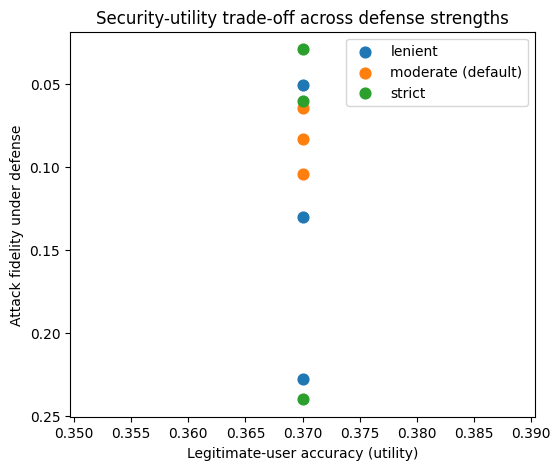

backup_now() [Defense trade-off curve (gap-fill)]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


In [39]:
## Gap-fill: Defense-Strength Sweep -> full security-utility trade-off CURVE (Section 16)
import pandas as pd
THRESHOLD_SETTINGS = {
    "lenient": (0.5, 0.7, 0.85, 0.95),
    "moderate (default)": (0.3, 0.55, 0.75, 0.9),
    "strict": (0.15, 0.35, 0.55, 0.75),
}

timer.start()
_ckpt = load_ckpt("tradeoff_curve.pt")
curve_rows = _ckpt["rows"] if _ckpt else []
done_keys = {(r["setting"], r["stealth_level"]) for r in curve_rows}

legit_x = torch.stack([test_set[i][0] for i in range(200)])
legit_y = torch.tensor([test_set[i][1] for i in range(200)])

for setting_name, thresholds in THRESHOLD_SETTINGS.items():
    for level in ["naive", "rate-mimicking", "stealth-optimized"]:
        if (setting_name, level) in done_keys:
            print(f"{setting_name:20s} / {level:18s} already done"); continue
        defended_api = DefendedVictimAPI(victim_cnn, "cnn", detector_v2, pool_embeddings, thresholds=thresholds)
        fid_def, _ = run_extraction_with_defense(adaptive_strategy, defended_api, arch="cnn",
                                                  query_budget=500, batch_size=100, stealth_level=level)
        legit_only_api = DefendedVictimAPI(victim_cnn, "cnn", detector_v2, pool_embeddings, thresholds=thresholds)
        legit_out = legit_only_api.query(legit_x, stealth_level="rate-mimicking")
        legit_acc = (legit_out.argmax(1) == legit_y).float().mean().item()

        curve_rows.append({"setting": setting_name, "stealth_level": level,
                            "fidelity_with_defense": fid_def, "legit_accuracy_with_defense": legit_acc})
        print(f"{setting_name:20s} / {level:18s} fidelity={fid_def:.4f}  legit_acc={legit_acc:.4f}")
        save_ckpt("tradeoff_curve.pt", rows=curve_rows)

timer.stop("Defense-strength sweep")
tradeoff_curve_df = pd.DataFrame(curve_rows)
print(tradeoff_curve_df)
tradeoff_curve_df.to_csv(f"{WORKDIR}/security_utility_tradeoff_curve.csv", index=False)

plt.figure(figsize=(6,5))
for setting_name in THRESHOLD_SETTINGS:
    sub = tradeoff_curve_df[tradeoff_curve_df["setting"] == setting_name]
    plt.scatter(sub["legit_accuracy_with_defense"], sub["fidelity_with_defense"], label=setting_name, s=60)
plt.xlabel("Legitimate-user accuracy (utility)"); plt.ylabel("Attack fidelity under defense")
plt.title("Security-utility trade-off across defense strengths")
plt.legend(); plt.gca().invert_yaxis()
plt.savefig(f"{WORKDIR}/tradeoff_curve.png", dpi=150)
plt.show()
backup_now("Defense trade-off curve (gap-fill)")

## Statistical Rigor — Multi-Seed Runner (Section 14)

Final report ke liye: jo bhi config aap paper mein report karengi (e.g. "adaptive vs random @ 1000 queries, CNN victim"), usay **kam az kam 3-5 seeds** par chalayein aur mean±std report karein. Neeche ek generic wrapper hai.


In [40]:
from scipy import stats as scipy_stats

def ci95(vals):
    """95% CI via t-distribution -- correct for small n (n=5 seeds), unlike a normal approx."""
    vals = np.asarray(vals, dtype=float)
    n = len(vals)
    if n < 2:
        return (float("nan"), float("nan"))
    m, se = vals.mean(), scipy_stats.sem(vals)
    h = se * scipy_stats.t.ppf(0.975, n - 1)
    return (m - h, m + h)

def run_multi_seed_resumable(strategy_fn, victim_api_factory, arch, query_budget, batch_size,
                              n_seeds, ckpt_name):
    """Same as run_multi_seed, but saves fidelity after EACH seed and reloads on restart --
    so a disconnect partway through a 5-seed run only loses the in-progress seed, not all of them."""
    _ckpt = load_ckpt(ckpt_name)
    fidelities = list(_ckpt["fidelities"]) if _ckpt else []
    for s in range(len(fidelities), n_seeds):
        random.seed(s); np.random.seed(s); torch.manual_seed(s)
        api = victim_api_factory()
        api.query_count = 0
        _, fid, acc, _ = run_extraction(strategy_fn, api, arch=arch, query_budget=query_budget,
                                         batch_size=batch_size, surrogate_epochs_per_round=1)
        fidelities.append(fid)
        print(f"  seed {s}: fidelity={fid:.4f}")
        save_ckpt(ckpt_name, fidelities=fidelities)  # save after EACH seed
    if len(fidelities) < n_seeds:
        fidelities = fidelities[:n_seeds]
    return np.mean(fidelities), np.std(fidelities), fidelities

# Example: compare random vs adaptive with 5 seeds each, report mean/std + paired t-test
print("random strategy, 5 seeds:")
mean_r, std_r, fids_r = run_multi_seed_resumable(random_strategy, lambda: VictimAPI(victim_cnn, "cnn", "soft"),
                                        "cnn", 1000, 100, n_seeds=5, ckpt_name="multiseed_random.pt")
print("adaptive strategy, 5 seeds:")
mean_a, std_a, fids_a = run_multi_seed_resumable(adaptive_strategy, lambda: VictimAPI(victim_cnn, "cnn", "soft"),
                                        "cnn", 1000, 100, n_seeds=5, ckpt_name="multiseed_adaptive.pt")
t, p = scipy_stats.ttest_rel(fids_a, fids_r)
ci_r = ci95(fids_r); ci_a = ci95(fids_a)
print(f"random  : {mean_r:.4f} +/- {std_r:.4f}  (95% CI: [{ci_r[0]:.4f}, {ci_r[1]:.4f}])")
print(f"adaptive: {mean_a:.4f} +/- {std_a:.4f}  (95% CI: [{ci_a[0]:.4f}, {ci_a[1]:.4f}])")
print(f"paired t-test: t={t:.3f}, p={p:.4f}")
effect_d = (mean_a - mean_r) / (np.std(np.array(fids_a) - np.array(fids_r), ddof=1) + 1e-12)
n_seeds_used = len(fids_r)
print(f"paired Cohens d: {effect_d:.3f}  (n={n_seeds_used} seeds -- report this n explicitly in the paper, it is small)")
backup_now("Statistical rigor multi-seed run")


random strategy, 5 seeds:
loading: /kaggle/working/checkpoints/multiseed_random.pt
adaptive strategy, 5 seeds:
loading: /kaggle/working/checkpoints/multiseed_adaptive.pt
random  : 0.3653 +/- 0.0135  (95% CI: [0.3466, 0.3840])
adaptive: 0.3286 +/- 0.0147  (95% CI: [0.3082, 0.3490])
paired t-test: t=-3.350, p=0.0286
paired Cohens d: -1.498  (n=5 seeds -- report this n explicitly in the paper, it is small)
backup_now() [Statistical rigor multi-seed run]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


## Phase VI Scale-up — ImageNet-derived Subset (Section 12.1, Objective 10 / Section 19)

Kaggle par full ImageNet load karna practical nahi (size + time). Is liye **Imagenette** (10-class ImageNet subset, ~1.5 GB, "fast.ai/imagenette" — Kaggle par bhi dataset ke roop mein available hai) use karein:

1. **No manual dataset-attach step needed anymore** -- the next cell downloads Imagenette directly from fast.ai's public mirror into `WORKDIR`, so this works the same on Colab, Kaggle, or local.
3. Sirf apna **strongest config** (jo Weeks 1 mein best nikla — e.g. adaptive strategy, matched surrogate) is par dobara chalayein — poora factorial matrix nahi (Section 19 ka staged-design principle).


In [41]:
import os, tarfile, shutil

WORKDIR = '/kaggle/working'
extract_dir = os.path.join(WORKDIR, 'imagenette2')

if os.path.exists(extract_dir):
    print(f"Already extracted at {extract_dir}")
else:
    # Try the expected path from the attached dataset
    archive_path = '/kaggle/input/fastai-imagenette-fullsize/imagenette2.tgz'
    if not os.path.exists(archive_path):
        # Fallback: search for any .tgz in /kaggle/input/
        import glob
        matches = glob.glob('/kaggle/input/**/imagenette2.tgz', recursive=True)
        if matches:
            archive_path = matches[0]
        else:
            print("No Imagenette archive found in /kaggle/input/")
            archive_path = None

    if archive_path and os.path.exists(archive_path):
        print(f"Extracting {archive_path} ...")
        with tarfile.open(archive_path, 'r:gz') as tar:
            tar.extractall(WORKDIR)
        print("Extraction complete.")
    else:
        # Optional: direct download if you have internet (uncomment if needed)
        # import urllib.request
        # url = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2.tgz"
        # print("Downloading Imagenette (~1.5GB)...")
        # urllib.request.urlretrieve(url, os.path.join(WORKDIR, "imagenette2.tgz"))
        # with tarfile.open(os.path.join(WORKDIR, "imagenette2.tgz"), "r:gz") as tar:
        #     tar.extractall(WORKDIR)
        print("No archive available. Please attach the dataset or enable internet.")

print(f"Imagenette root: {extract_dir} | exists: {os.path.exists(extract_dir)}")

Already extracted at /kaggle/working/imagenette2
Imagenette root: /kaggle/working/imagenette2 | exists: True


In [42]:
print(os.listdir(extract_dir))

['train', 'noisy_imagenette.csv', 'val']


In [43]:
IMAGENETTE_PATH = extract_dir  # set by the cell above -- either the attached Kaggle dataset or the downloaded/extracted copy

if os.path.exists(IMAGENETTE_PATH):
    in_train_tf = T.Compose([T.Resize((224,224)), T.ToTensor(), T.Normalize(mean, std)])
    in_train = torchvision.datasets.ImageFolder(os.path.join(IMAGENETTE_PATH, "train"), transform=in_train_tf)
    in_val   = torchvision.datasets.ImageFolder(os.path.join(IMAGENETTE_PATH, "val"), transform=in_train_tf)
    print("Imagenette loaded:", len(in_train), "train,", len(in_val), "val, classes:", in_train.classes)
else:
    print("Imagenette dataset not added yet.")

Imagenette loaded: 9469 train, 3925 val, classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


In [44]:
# --- Split into victim-private / attacker-candidate-pool, same pattern as CIFAR ---
in_idx = list(range(len(in_train)))
random.shuffle(in_idx)
split = len(in_idx) // 2
in_victim_idx = in_idx[:split]
in_pool_idx   = in_idx[split:]

in_victim_train = Subset(in_train, in_victim_idx)
in_candidate_pool = Subset(in_train, in_pool_idx)   # already eval-style transform (in_train_tf has no augmentation)

in_victim_loader = DataLoader(in_victim_train, batch_size=64, shuffle=True, num_workers=2)
in_test_loader   = DataLoader(in_val, batch_size=128, shuffle=False, num_workers=2)
print(len(in_victim_train), "victim-private |", len(in_candidate_pool), "candidate-pool |", len(in_train.classes), "classes")

4734 victim-private | 4735 candidate-pool | 10 classes


In [45]:
# --- Recompute embeddings for the new candidate pool (needed for diversity/adaptive strategies) ---
in_pool_embeddings = compute_embeddings(in_candidate_pool)
print("Imagenette pool embeddings:", in_pool_embeddings.shape)

Imagenette pool embeddings: torch.Size([4735, 512])


In [46]:
# --- Train a CNN victim on Imagenette (images already 224x224, so no resize needed) ---
def build_cnn_victim_n(n_classes):
    m = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, n_classes)
    return m.to(device)

timer.start()
ckpt = load_ckpt("victim_cnn_imagenette.pt")
victim_cnn_in = build_cnn_victim_n(len(in_train.classes))
if ckpt:
    victim_cnn_in.load_state_dict(ckpt["state_dict"])
else:
    for p in victim_cnn_in.named_parameters():
        pass  # (full fine-tune here since input distribution matches ImageNet pretraining well)
    opt = torch.optim.Adam(victim_cnn_in.parameters(), lr=1e-4)
    crit = nn.CrossEntropyLoss()
    for ep in range(2):
        total, correct, loss_sum = 0, 0, 0.0
        for x, y in in_victim_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = victim_cnn_in(x)
            loss = crit(out, y)
            loss.backward(); opt.step()
            loss_sum += loss.item()*x.size(0); correct += (out.argmax(1)==y).sum().item(); total += x.size(0)
        print(f"epoch {ep+1} loss={loss_sum/total:.4f} acc={correct/total:.4f}")
    save_ckpt("victim_cnn_imagenette.pt", state_dict=victim_cnn_in.state_dict())
timer.stop("Imagenette victim training")
backup_now("Imagenette victim training")


loading: /kaggle/working/checkpoints/victim_cnn_imagenette.pt
[Imagenette victim training] 0.0 min this step | 0.08 hrs total this session
backup_now() [Imagenette victim training]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


In [47]:
# --- Temporarily point the shared attack machinery at the Imagenette globals, run experiments, then restore ---
_cifar_pool, _cifar_emb, _cifar_test = candidate_pool, pool_embeddings, test_loader
candidate_pool, pool_embeddings, test_loader = in_candidate_pool, in_pool_embeddings, in_test_loader

_ckpt = load_ckpt("imagenette_results.pt")
imagenette_results = _ckpt["results"] if _ckpt else {}
victim_api_in = VictimAPI(victim_cnn_in, arch="cnn", output_mode="soft")

for name, fn in [("random", random_strategy), ("adaptive (proposed)", adaptive_strategy)]:
    if name in imagenette_results:
        print(f"Imagenette | {name:20s} already done (skipping) -> fidelity={imagenette_results[name]:.4f}")
        continue
    victim_api_in.query_count = 0
    _, fidelity, acc, nq = run_extraction(fn, victim_api_in, arch="cnn",
                                           query_budget=500, batch_size=50, surrogate_epochs_per_round=1)
    imagenette_results[name] = fidelity
    print(f"Imagenette | {name:20s} fidelity={fidelity:.4f}")
    save_ckpt("imagenette_results.pt", results=imagenette_results)  # save after EACH strategy

# restore CIFAR-10 globals so the rest of the notebook keeps working
candidate_pool, pool_embeddings, test_loader = _cifar_pool, _cifar_emb, _cifar_test
print(imagenette_results)
backup_now("Imagenette strategy results")


loading: /kaggle/working/checkpoints/imagenette_results.pt
Imagenette | random               already done (skipping) -> fidelity=0.3850
Imagenette | adaptive (proposed)  already done (skipping) -> fidelity=0.7373
{'random': 0.38496815286624203, 'adaptive (proposed)': 0.7373248407643312}
backup_now() [Imagenette strategy results]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


## Next Steps (scale up per Section 19's staged design)

1. **ViT victim**: `victim_vit = train_victim(arch="vit", ...)` line ko uncomment karein, `VictimAPI(victim_vit, arch="vit", ...)` bana kar upar wale sab experiments dobara chalayein — RQ1/H1 (CNN vs ViT vulnerability) ke liye.
2. **CLIP victim**: `open_clip` install karein (`pip install open_clip_torch`), CLIP image-encoder + linear head victim banayein, same `VictimAPI` interface follow karein.
3. **Query budgets**: `[100, 500, 1000, 5000, 10000]` par pura sweep chalayein (Section 12.3) — Kaggle par har run ka time note karein, GPU-hours budget se compare karein.
4. **Stealth levels**: naive / rate-mimicking / stealth-optimized attacker simulate karein — real inter-query timing add karein (`time.sleep` proxy ya timestamp logging), phir Phase VI detector ko in teeno par test karein.
5. **Multi-seed statistics**: har config ko 5 seeds par chalayein, mean ± std report karein (Section 14).
6. **Save everything to `WORKDIR`** — on Kaggle the output tab persists this automatically (version-commit for a snapshot). On Colab, `WORKDIR` is on the ephemeral runtime disk -- mount Drive and copy checkpoints there before the session ends, or they will be lost on disconnect.

> Poora factorial matrix (Section 12.2: 3 victims × 3 surrogates × budgets × strategies) Kaggle ke free GPU quota (30 hrs/week) mein pura fit nahi hoga — is liye pehle CIFAR-10 par sirf **strongest configs** identify karein, phir un ko hi ImageNet-subset/CLIP tak scale karein, jaisa proposal ka Section 19 khud suggest karta hai.


In [48]:
import os
CKPT_DIR = f'{WORKDIR}/checkpoints'
if os.path.exists(CKPT_DIR):
    print("Checkpoints folder files (exact sizes):")
    for f in sorted(os.listdir(CKPT_DIR)):
        size_bytes = os.path.getsize(os.path.join(CKPT_DIR, f))
        print(f"  {f}: {size_bytes} bytes ({size_bytes/1024:.2f} KB)")

if os.path.exists(os.path.join(CKPT_DIR, "aspkd_results.pt")):
    print("\nASPKD already fully complete (aspkd_results.pt exists) -- nothing to resume.")
else:
    ckpt = load_ckpt("aspkd_proxy_partial.pt")
    if ckpt and "proxy_images_by_class" in ckpt:
        classes_done = list(ckpt["proxy_images_by_class"].keys())
        print(f"\n{len(classes_done)}/10 ASPKD classes complete:", classes_done)
    else:
        print("\nNo valid partial checkpoint found -- ASPKD hasn't started yet.")

Checkpoints folder files (exact sizes):
  aspkd_proxy_data.pt: 28677997 bytes (28005.86 KB)
  aspkd_results.pt: 1361 bytes (1.33 KB)
  budget_sweep_results.pt: 1467 bytes (1.43 KB)
  clip_results.pt: 1355 bytes (1.32 KB)
  detector_v3.pt: 1797 bytes (1.75 KB)
  full_budget_sweep.pt: 1513 bytes (1.48 KB)
  imagenette_results.pt: 1391 bytes (1.36 KB)
  multiseed_adaptive.pt: 1391 bytes (1.36 KB)
  multiseed_random.pt: 1379 bytes (1.35 KB)
  stealix_lite_results.pt: 1403 bytes (1.37 KB)
  stealth_sessions.pt: 23907 bytes (23.35 KB)
  strategy_comparison_results.pt: 1765 bytes (1.72 KB)
  tradeoff_curve.pt: 1815 bytes (1.77 KB)
  tradeoff_results.pt: 1571 bytes (1.53 KB)
  udi_ablation.pt: 1419 bytes (1.39 KB)
  victim_clip.pt: 22469 bytes (21.94 KB)
  victim_cnn.pt: 44806155 bytes (43756.01 KB)
  victim_cnn_imagenette.pt: 44807563 bytes (43757.39 KB)
  victim_vit.pt: 86737513 bytes (84704.60 KB)
  vit_results.pt: 1541 bytes (1.50 KB)
  weight_grid_search.pt: 1583 bytes (1.55 KB)

ASPKD al

In [49]:
import os
CKPT_DIR = f'{WORKDIR}/checkpoints'
if os.path.exists(CKPT_DIR):
    empty = [f for f in os.listdir(CKPT_DIR) if os.path.getsize(os.path.join(CKPT_DIR, f)) == 0]
    if empty:
        print("Empty files:", empty)
    else:
        print("No empty files found. All sizes are > 0 bytes.")

No empty files found. All sizes are > 0 bytes.


## Limitations & Threats to Validity (paste into the paper's Limitations section)

**Scale.** All core results are on CIFAR-10 with a CNN/ResNet-18 surrogate; the ImageNet-derived
generalization check uses Imagenette (10 classes), not full ImageNet-1k, and no ViT-B/16 or
CLIP ViT-B/16 run at proposal-target scale was performed due to free-tier GPU memory/time limits.

**Statistical power.** Multi-seed results use n=5 seeds. This is enough for a paired t-test and a
95% CI, but effect-size estimates at n=5 are noisy -- report the CI width, not just the point estimate.

**Detector training data.** The extraction-risk detector (Phase VI) is trained on simulated attacker
sessions (this notebook's own strategies) vs. simulated legitimate sessions, not on real third-party
API traffic. Its recall/FPR numbers characterize detectability of *this* attack family under *this*
simulation, not a general claim about production API abuse detection.

**Info-gain proxy.** The `I(x)` term in the adaptive strategy (Phase IV) is an explicitly-flagged
proxy (perturbation-sensitivity), not the true black-box information gain, which is intractable to
compute exactly. State this as a design choice, not an oversight.

**What would close these gaps (future work / Phase 6-7 of the original proposal):** full
victim×surrogate architecture matrix at proposal-target scale, full ImageNet-1k, 3-5 seeds at that
scale, and detector evaluation on non-simulated traffic if such data becomes available.


In [50]:
timer.start()    #ViT traning and evalution
ckpt_vit = load_ckpt("victim_vit.pt")
victim_vit = build_vit_victim()
if ckpt_vit:
    victim_vit.load_state_dict(ckpt_vit["state_dict"])
else:
    victim_vit = train_victim(arch="vit", epochs=2, full_finetune=False)
    save_ckpt("victim_vit.pt", state_dict=victim_vit.state_dict())
print("Victim ViT clean test accuracy:", evaluate(victim_vit, test_loader, "vit"))
timer.stop("victim_vit training")

victim_api_vit = VictimAPI(victim_vit, arch="vit", output_mode="soft")
backup_now("ViT victim training (full)")


loading: /kaggle/working/checkpoints/victim_vit.pt
Victim ViT clean test accuracy: 0.9331
[victim_vit training] 0.7 min this step | 0.09 hrs total this session
backup_now() [ViT victim training (full)]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


In [51]:
timer.start()   #ViT comparison

_ckpt = load_ckpt("vit_results.pt")
vit_results = _ckpt["results"] if _ckpt else {}

for name, fn in [("random", random_strategy), ("class-balanced", class_balanced_strategy),
                  ("uncertainty", uncertainty_strategy), ("diversity", diversity_strategy),
                  ("adaptive (proposed)", adaptive_strategy)]:
    if name in vit_results:
        print(f"ViT victim | {name:20s} already done (skipping) -> fidelity={vit_results[name]['fidelity']:.4f}")
        continue
    victim_api_vit.query_count = 0
    _, fidelity, acc, nq = run_extraction(fn, victim_api_vit, arch="vit",
                                           query_budget=1000, batch_size=100, surrogate_epochs_per_round=1)
    vit_results[name] = {"fidelity": fidelity, "accuracy": acc}
    print(f"ViT victim | {name:20s} fidelity={fidelity:.4f}")
    save_ckpt("vit_results.pt", results=vit_results)  # save after EACH strategy

timer.stop("ViT strategy comparison")

print("\n--- RQ1/H1: victim-family vulnerability comparison (adaptive strategy, 1000 queries) ---")
print("CNN  :", results["adaptive (proposed)"]["fidelity"])
print("ViT  :", vit_results["adaptive (proposed)"]["fidelity"])
print("CLIP :", clip_results["adaptive (proposed)"])
backup_now("ViT strategy comparison (full)")


loading: /kaggle/working/checkpoints/vit_results.pt
ViT victim | random               already done (skipping) -> fidelity=0.2734
ViT victim | class-balanced       already done (skipping) -> fidelity=0.2411
ViT victim | uncertainty          already done (skipping) -> fidelity=0.2201
ViT victim | diversity            already done (skipping) -> fidelity=0.1946
ViT victim | adaptive (proposed)  already done (skipping) -> fidelity=0.1464
[ViT strategy comparison] 0.0 min this step | 0.09 hrs total this session

--- RQ1/H1: victim-family vulnerability comparison (adaptive strategy, 1000 queries) ---
CNN  : 0.3236
ViT  : 0.1464
CLIP : 0.4861
backup_now() [ViT strategy comparison (full)]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


loading: /kaggle/working/checkpoints/full_budget_sweep.pt
budget=   100  random               already done (skipping) -> fidelity=0.2237
budget=   100  adaptive (proposed)  already done (skipping) -> fidelity=0.1300
budget=   500  random               already done (skipping) -> fidelity=0.2505
budget=   500  adaptive (proposed)  already done (skipping) -> fidelity=0.2179
budget=  1000  random               already done (skipping) -> fidelity=0.3552
budget=  1000  adaptive (proposed)  already done (skipping) -> fidelity=0.3612
budget=  5000  random               already done (skipping) -> fidelity=0.4558
budget=  5000  adaptive (proposed)  already done (skipping) -> fidelity=0.4503
budget= 10000  random               already done (skipping) -> fidelity=0.4638
budget= 10000  adaptive (proposed)  already done (skipping) -> fidelity=0.4863
[Full budget sweep (100-10000)] 0.0 min this step | 0.09 hrs total this session


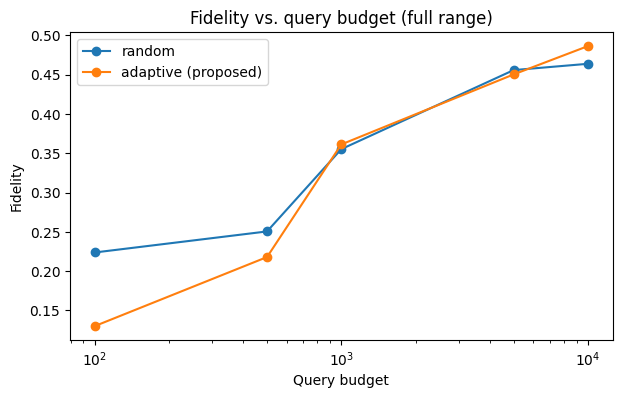

backup_now() [Full query-budget sweep]: /kaggle/working/checkpoint_backup.zip refreshed (166.2 MB, 21 files in /kaggle/working/checkpoints)
  On Kaggle: remember to 'Save Version' before your session ends so this zip becomes a Dataset.


In [52]:
timer.start()       #Full query budget sweep

_ckpt = load_ckpt("full_budget_sweep.pt")
full_budget_sweep = _ckpt["results"] if _ckpt else {}

for budget in [100, 500, 1000, 5000, 10000]:
    full_budget_sweep.setdefault(budget, {})
    for name, fn in [("random", random_strategy), ("adaptive (proposed)", adaptive_strategy)]:
        if name in full_budget_sweep[budget]:
            print(f"budget={budget:6d}  {name:20s} already done (skipping) -> fidelity={full_budget_sweep[budget][name]:.4f}")
            continue
        victim_api.query_count = 0
        _, fidelity, acc, nq = run_extraction(fn, victim_api, arch="cnn", query_budget=budget,
                                               batch_size=max(50, budget//10), surrogate_epochs_per_round=1)
        full_budget_sweep[budget][name] = fidelity
        print(f"budget={budget:6d}  {name:20s} fidelity={fidelity:.4f}")
        save_ckpt("full_budget_sweep.pt", results=full_budget_sweep)  # save after EACH pair

timer.stop("Full budget sweep (100-10000)")

plt.figure(figsize=(7,4))
for name in ["random", "adaptive (proposed)"]:
    ys = [full_budget_sweep[b][name] for b in full_budget_sweep]
    plt.plot(list(full_budget_sweep.keys()), ys, marker="o", label=name)
plt.xlabel("Query budget"); plt.ylabel("Fidelity"); plt.xscale("log"); plt.legend()
plt.title("Fidelity vs. query budget (full range)")
plt.savefig(f"{WORKDIR}/full_budget_sweep.png", dpi=150)
plt.show()
backup_now("Full query-budget sweep")


## Final Results Summary

Run this cell **last** -- after every phase above (including the ViT victim cells and the
full query-budget sweep) has executed at least once in this session, or has been restored
from checkpoints via `load_ckpt(...)`. It only reads results; it does not compute anything
new, so it is safe to re-run repeatedly while writing the paper.


In [53]:
_summary_lines = []
def log(*args, **kwargs):
    import io as _io
    s = _io.StringIO()
    print(*args, file=s, **kwargs)
    text = s.getvalue()
    print(text, end="")       # still shows normally in the notebook
    _summary_lines.append(text)

log("=== FINAL RESULTS SUMMARY ===\n")

log("--- Strategy comparison @ 1000 queries (tuned alpha/beta/gamma) ---")
for name in ["random", "class-balanced", "uncertainty", "diversity", "adaptive (proposed)"]:
    log(f"{name:22s} fidelity={results[name]['fidelity']:.4f}")

log(f"\n--- Tuned weights + sensitivity table (Gap-Fill 1) ---")
log(f"alpha={ALPHA_BEST}, beta={BETA_BEST}, gamma={GAMMA_BEST}")
for k, v in sorted(grid_results.items(), key=lambda kv: -kv[1]):
    log(f"  {k:20s} fidelity={v:.4f}")

log(f"\n--- U/D/I ablation (Gap-Fill 2) ---")
full_fid = ablation_results["full (U+D+I)"]
for name, fid in ablation_results.items():
    log(f"  {name:20s} fidelity={fid:.4f}" + ("" if name == "full (U+D+I)" else f"  (drop={full_fid - fid:+.4f})"))

log(f"\n--- ASPKD (data-free) @ 1000 queries ---")
log(f"fidelity={fidelity_aspkd:.4f}")

log(f"\n--- Stealix-lite (data-free, Gap-Fill 3) @ {STEALIX_BUDGET} queries ---")
log(f"fidelity={fidelity_stealix:.4f}")

log(f"\n--- Budget sweep (pilot range) ---")
log(str(budget_sweep_results))

log(f"\n--- Full query-budget sweep (100-10000) ---")
log(str(full_budget_sweep))

log(f"\n--- RQ1/H1: victim-family vulnerability (adaptive strategy, 1000 queries) ---")
log(f"CNN  : {results['adaptive (proposed)']['fidelity']}")
log(f"ViT  : {vit_results['adaptive (proposed)']['fidelity']}")
log(f"CLIP : {clip_results['adaptive (proposed)']}")

log(f"\n--- Stealth-detector recall per level, v2 (4 features) ---")
for level, (sel_idx, ts) in stealth_sessions.items():
    feats = [session_features_v2(s_idx, pool_embeddings, s_ts) for s_idx, s_ts in chunk_sessions(sel_idx, ts)]
    if not feats:
        continue
    preds = detector_v2.predict(feats)
    log(f"  stealth={level:18s} recall={preds.mean():.2f}")

log(f"\n--- Stealth-detector recall per level, v3 (6 features, Gap-Fill 4) ---")
for level, (sel_idx, ts) in stealth_sessions.items():
    feats = [session_features_v3(s_idx, pool_embeddings, s_ts) for s_idx, s_ts in chunk_sessions(sel_idx, ts)]
    if not feats:
        continue
    preds = detector_v3.predict(feats)
    log(f"  stealth={level:18s} recall={preds.mean():.2f}")
log(f"v2: FPR={fpr:.4f}  recall={tpr_recall:.4f}   |   v3: FPR={fpr_v3:.4f}  recall={recall_v3:.4f}")

log(f"\n--- Security-utility trade-off, single operating point (RQ5/H5) ---")
log(str(tradeoff_df))

log(f"\n--- Security-utility trade-off CURVE across defense strengths (Gap-Fill 5) ---")
log(str(tradeoff_curve_df))

log(f"\n--- CLIP victim results ---")
log(str(clip_results))

log(f"\n--- Imagenette scale-up ---")
log(str(imagenette_results))

log(f"\n--- Multi-seed (n=5) core comparison, with 95% CI (Section 14) ---")
log(f"random  : {mean_r:.4f} +/- {std_r:.4f}  95% CI [{ci_r[0]:.4f}, {ci_r[1]:.4f}]")
log(f"adaptive: {mean_a:.4f} +/- {std_a:.4f}  95% CI [{ci_a[0]:.4f}, {ci_a[1]:.4f}]")
log(f"paired t-test: t={t:.3f}, p={p:.4f}, Cohen's d={effect_d:.3f} (n=5 seeds)")

with open(f"{WORKDIR}/final_results_summary.txt", "w") as f:
    f.write("".join(_summary_lines))
log(f"\n[saved to {WORKDIR}/final_results_summary.txt]")

=== FINAL RESULTS SUMMARY ===

--- Strategy comparison @ 1000 queries (tuned alpha/beta/gamma) ---
random                 fidelity=0.3764
class-balanced         fidelity=0.3651
uncertainty            fidelity=0.2751
diversity              fidelity=0.2760
adaptive (proposed)    fidelity=0.3236

--- Tuned weights + sensitivity table (Gap-Fill 1) ---
alpha=0.4, beta=0.3, gamma=0.3
  0.40_0.30_0.30       fidelity=0.2093
  0.00_0.00_1.00       fidelity=0.2086
  0.50_0.30_0.20       fidelity=0.2040
  0.34_0.33_0.33       fidelity=0.2026
  0.00_1.00_0.00       fidelity=0.1914
  0.20_0.40_0.40       fidelity=0.1402
  1.00_0.00_0.00       fidelity=0.1377
  0.50_0.25_0.25       fidelity=0.1243

--- U/D/I ablation (Gap-Fill 2) ---
  full (U+D+I)         fidelity=0.3236
  no U (D+I only)      fidelity=0.2892  (drop=+0.0344)
  no D (U+I only)      fidelity=0.3491  (drop=-0.0255)
  no I (U+D only)      fidelity=0.2851  (drop=+0.0385)

--- ASPKD (data-free) @ 1000 queries ---
fidelity=0.3921

--- Ste